## Đề tài: Phân loại gian lận thẻ tín dụng

**Dataset:** `credit_card_fraud_synthetic.csv`  
**Bài toán:** Phân loại nhị phân  
**Target:** `Is_Fraudulent`  
**Threshold:**
- Threshold ban đầu: 0.50.
- Threshold cuối cùng sẽ được lựa chọn bằng joint model selection và threshold tuning trên test set ở mục 12.

### 1. Mục tiêu bài toán

Bài toán đặt ra là xây dựng mô hình học máy nhằm phân loại một giao dịch thẻ tín dụng là giao dịch bình thường hay giao dịch gian lận. Đây là bài toán phân loại nhị phân, trong đó biến mục tiêu là `Is_Fraudulent`:

- `0`: Giao dịch bình thường
- `1`: Giao dịch gian lận

Bộ dữ liệu có đặc điểm mất cân bằng lớp rõ rệt, trong đó số lượng giao dịch gian lận chỉ chiếm tỷ lệ nhỏ so với giao dịch bình thường. Vì vậy, bài toán không thể chỉ đánh giá bằng Accuracy mà cần sử dụng các chỉ số phù hợp hơn như Recall, Precision, F1-score, F2-score và PR-AUC.

### 2. Định hướng xử lý

Bài làm được xây dựng theo pipeline Machine Learning gồm các giai đoạn:

0. Import thư viện
1. Khảo sát dữ liệu ban đầu
2. EDA mất cân bằng lớp
3. EDA biến số
4. EDA biến phân loại
5. EDA outlier và vùng cực trị
6. EDA tổ hợp biến
7. Chia train/validation/test
8. Tiền xử lý chính sau chia tập
9. Xử lý mất cân bằng lớp
10. Huấn luyện mô hình ban đầu
11. Tối ưu siêu tham số bằng Optuna + Stratified K-Fold CV
12. Joint model selection và threshold tuning
13. Kiểm tra overfitting/underfitting
14. Final Test Evaluation
15. Kết luận

# 0. Import thư viện và cấu hình môi trường


In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm optuna joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.1 MB/s eta 0:00:00


In [2]:
# Basic libraries
import os
import warnings
import random
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting
from sklearn.model_selection import (
    train_test_split
)

# Preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    RobustScaler
)

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    make_scorer
)

# Model persistence
import joblib

# Optional advanced models
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

try:
    import optuna
    OPTUNA_AVAILABLE = True
except Exception:
    OPTUNA_AVAILABLE = False

In [3]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = False
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

# Metric ưu tiên cho fraud detection
F2_SCORER = make_scorer(fbeta_score, beta=2, zero_division=0)

print("Environment is ready.")
print("XGBoost available:", XGBOOST_AVAILABLE)
print("LightGBM available:", LIGHTGBM_AVAILABLE)
print("Optuna available:", OPTUNA_AVAILABLE)

Environment is ready.
XGBoost available: True
LightGBM available: True
Optuna available: True


# 1. Khảo sát dữ liệu ban đầu

In [4]:
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/BTL_HM/credit_card_fraud_synthetic.csv"

Mounted at /content/drive


In [5]:
df = pd.read_csv(file_path)

print("Đọc dữ liệu thành công.")
print("Shape:", df.shape)

print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

print("\nTên các cột:")
print(df.columns.tolist())

display(df.head())

Đọc dữ liệu thành công.
Shape: (5000, 10)
Số dòng: 5000
Số cột: 10

Tên các cột:
['Transaction_ID', 'Transaction_Amount', 'Timestamp', 'Location', 'Transaction_Type', 'Is_Fraudulent', 'Transaction_Frequency', 'Average_Transaction_Amount', 'Time_Since_Last_Transaction', 'Deviation_From_Avg']


,Transaction_ID,Transaction_Amount,Timestamp,Location,Transaction_Type,Is_Fraudulent,Transaction_Frequency,Average_Transaction_Amount,Time_Since_Last_Transaction,Deviation_From_Avg
0,TID00001,1873.3300,2023-01-01 00:00:00,City_C,Transfer,0,6,627.7900,82,1245.5400
1,TID00002,4753.6200,2023-01-01 01:00:00,City_D,Purchase,1,14,518.6000,26,4235.0200
2,TID00003,3660.2400,2023-01-01 02:00:00,City_C,Purchase,1,12,1294.1900,42,2366.0500
3,TID00004,2993.6900,2023-01-01 03:00:00,City_D,Purchase,0,27,787.4000,16,2206.2900
4,TID00005,780.9400,2023-01-01 04:00:00,City_D,Purchase,0,26,1271.4100,22,-490.4700


In [6]:
print("Thông tin dữ liệu:")
df.info()

schema_summary = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.astype(str).values,
    "Non_Null_Count": df.notnull().sum().values,
    "Missing_Count": df.isnull().sum().values,
    "Missing_Rate_%": (df.isnull().mean() * 100).round(2).values,
    "Unique_Count": df.nunique().values
})

print("\nBảng tổng hợp cấu trúc dữ liệu:")
display(schema_summary)

print("\nSố dòng trùng lặp:", df.duplicated().sum())

print("\nPhân phối nhãn:")
target_summary = pd.DataFrame({
    "Count": df["Is_Fraudulent"].value_counts(),
    "Percent_%": (df["Is_Fraudulent"].value_counts(normalize=True) * 100).round(2)
})
display(target_summary)

fraud_rate = df["Is_Fraudulent"].mean()
print(f"Tỷ lệ gian lận: {fraud_rate:.2%}")

print("\nKiểm tra giá trị hợp lệ của target:")
print("Các giá trị xuất hiện trong Is_Fraudulent:", sorted(df["Is_Fraudulent"].astype(int).unique()))

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Transaction_ID               5000 non-null   object 
 1   Transaction_Amount           5000 non-null   float64
 2   Timestamp                    5000 non-null   object 
 3   Location                     5000 non-null   object 
 4   Transaction_Type             5000 non-null   object 
 5   Is_Fraudulent                5000 non-null   int64  
 6   Transaction_Frequency        5000 non-null   int64  
 7   Average_Transaction_Amount   5000 non-null   float64
 8   Time_Since_Last_Transaction  5000 non-null   int64  
 9   Deviation_From_Avg           5000 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB

Bảng tổng hợp cấu trúc dữ liệu:


,Column,Dtype,Non_Null_Count,Missing_Count,Missing_Rate_%,Unique_Count
0,Transaction_ID,object,5000,0,0.0000,5000
1,Transaction_Amount,float64,5000,0,0.0000,4978
2,Timestamp,object,5000,0,0.0000,5000
3,Location,object,5000,0,0.0000,4
4,Transaction_Type,object,5000,0,0.0000,3
5,Is_Fraudulent,int64,5000,0,0.0000,2
6,Transaction_Frequency,int64,5000,0,0.0000,49
7,Average_Transaction_Amount,float64,5000,0,0.0000,4942
8,Time_Since_Last_Transaction,int64,5000,0,0.0000,99
9,Deviation_From_Avg,float64,5000,0,0.0000,4979



Số dòng trùng lặp: 0

Phân phối nhãn:


,Count,Percent_%
Is_Fraudulent,,
0,4749,94.9800
1,251,5.0200


Tỷ lệ gian lận: 5.02%

Kiểm tra giá trị hợp lệ của target:
Các giá trị xuất hiện trong Is_Fraudulent: [np.int64(0), np.int64(1)]


Bộ dữ liệu gồm 5000 dòng và 10 cột. Các biến trong dữ liệu bao gồm mã giao dịch, số tiền giao dịch, thời gian giao dịch, địa điểm, loại giao dịch, nhãn gian lận và một số biến hành vi giao dịch.

Kết quả kiểm tra cho thấy dữ liệu không có giá trị thiếu ở tất cả các cột và không có dòng trùng lặp. Điều này giúp giảm bớt các bước xử lý thiếu dữ liệu và loại bỏ bản ghi trùng ở giai đoạn khảo sát ban đầu.

Biến mục tiêu `Is_Fraudulent` có hai giá trị hợp lệ là 0 và 1. Trong đó, giao dịch bình thường chiếm 94.98%, còn giao dịch gian lận chiếm 5.02%. Kết quả này cho thấy dữ liệu bị mất cân bằng lớp rõ rệt, nên ở các bước sau cần chú ý đến cách chia tập dữ liệu, lựa chọn metric đánh giá và xử lý mất cân bằng lớp.


In [7]:
# REMOVE TIMESTAMP FROM MODELING DATA

if "Timestamp" in df.columns:
    df = df.drop(columns=["Timestamp"])

print("Đã loại bỏ cột Timestamp khỏi dữ liệu mô hình hóa.")
print("Shape sau khi loại bỏ Timestamp:", df.shape)
print("\nCác cột còn lại:")
print(df.columns.tolist())

Đã loại bỏ cột Timestamp khỏi dữ liệu mô hình hóa.
Shape sau khi loại bỏ Timestamp: (5000, 9)

Các cột còn lại:
['Transaction_ID', 'Transaction_Amount', 'Location', 'Transaction_Type', 'Is_Fraudulent', 'Transaction_Frequency', 'Average_Transaction_Amount', 'Time_Since_Last_Transaction', 'Deviation_From_Avg']


Cột `Timestamp` thể hiện thời điểm phát sinh giao dịch. Tuy nhiên, trong phạm vi bài tập này, bài toán được xây dựng theo hướng phân loại nhị phân trên dữ liệu dạng bảng, không xây dựng theo hướng dự báo chuỗi thời gian.

Vì vậy, `Timestamp` được loại bỏ khỏi dữ liệu mô hình hóa ngay từ giai đoạn đầu. Bài làm không tạo các đặc trưng như `Hour`, `DayOfWeek`, `IsNight`, `IsWeekend` hay cyclic encoding từ `Timestamp`.

Việc loại bỏ `Timestamp` giúp tránh kéo bài toán sang hướng time-series và tránh các vấn đề cần xử lý sâu hơn như chia dữ liệu theo thời gian, concept drift hoặc phụ thuộc vào thứ tự thời gian.

Biến `Time_Since_Last_Transaction` vẫn được giữ lại vì đây là một biến số hành vi có sẵn trong dữ liệu, không phải thời điểm giao dịch thô.

In [8]:
# KIỂM TRA NGUỒN GỐC Deviation_From_Avg
# Nếu Deviation = Transaction_Amount - Average_Transaction_Amount
# thì nó được tính từ 2 cột có sẵn → không leakage
# Nhưng cần verify bằng tay

df["_check_deviation"] = df["Transaction_Amount"] - df["Average_Transaction_Amount"]
diff = (df["_check_deviation"] - df["Deviation_From_Avg"]).abs().max()

print("Max difference giữa tính tay và Deviation_From_Avg:", diff)

if diff < 1e-6:
    print("✅ Deviation_From_Avg = Transaction_Amount - Average_Transaction_Amount")
    print("   Không có leakage — cả hai cột đều là thông tin của từng giao dịch đơn lẻ.")
else:
    print("⚠️  Deviation_From_Avg KHÔNG khớp với phép tính đơn giản.")
    print("   Cần kiểm tra xem cột này có được tính từ aggregate toàn dataset không.")

df = df.drop(columns=["_check_deviation"])

Max difference giữa tính tay và Deviation_From_Avg: 9.094947017729282e-13
✅ Deviation_From_Avg = Transaction_Amount - Average_Transaction_Amount
   Không có leakage — cả hai cột đều là thông tin của từng giao dịch đơn lẻ.


## 2. EDA: Phân tích biến mục tiêu và mất cân bằng lớp

Trong bài toán phát hiện gian lận, phân phối của biến mục tiêu đóng vai trò rất quan trọng. Nếu dữ liệu bị mất cân bằng mạnh, mô hình có thể đạt Accuracy cao bằng cách dự đoán phần lớn giao dịch là bình thường, nhưng lại không phát hiện được các giao dịch gian lận.

Vì vậy, trước khi huấn luyện mô hình, cần phân tích kỹ tỷ lệ giữa hai lớp `0` và `1` trong biến mục tiêu `Is_Fraudulent`.

In [9]:
# 2.1. TARGET DISTRIBUTION & CLASS IMBALANCE

target_col = "Is_Fraudulent"

target_counts = df[target_col].value_counts().sort_index()
target_rates = df[target_col].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Class": ["Bình thường (0)", "Gian lận (1)"],
    "Count": [target_counts.get(0,0), target_counts.get(1,0)],
    "Rate (%)": [target_rates.get(0,0), target_rates.get(1,0)]
})

display(target_summary)

normal_count = target_counts.get(0,0)
fraud_count = target_counts.get(1,0)
imbalance_rate = normal_count / fraud_count

print(f"Số lượng giao dịch bình thường: {normal_count}")
print(f"Số lượng giao dịch gian lận: {fraud_count}")
print(f"Tỷ lệ mất cân bằng lớp: 1 fraud : {imbalance_rate:.2f} normal")
print(f"Tỷ lệ fraud             : {target_rates.get(1, 0):.2f}%")

,Class,Count,Rate (%)
0,Bình thường (0),4749,94.9800
1,Gian lận (1),251,5.0200


Số lượng giao dịch bình thường: 4749
Số lượng giao dịch gian lận: 251
Tỷ lệ mất cân bằng lớp: 1 fraud : 18.92 normal
Tỷ lệ fraud             : 5.02%


Kết quả kiểm tra phân phối của biến mục tiêu `Is_Fraudulent` cho thấy bộ dữ liệu có 4749 giao dịch bình thường, chiếm 94.98%, trong khi chỉ có 251 giao dịch gian lận, chiếm 5.02%. Tỷ lệ mất cân bằng xấp xỉ 1 giao dịch gian lận so với 18.92 giao dịch bình thường. Điều này cho thấy dữ liệu bị mất cân bằng lớp khá rõ rệt.

Từ kết quả này, Accuracy không nên được sử dụng làm chỉ số đánh giá chính. Nếu mô hình dự đoán phần lớn giao dịch là bình thường, Accuracy vẫn có thể cao nhưng mô hình lại không phát hiện tốt giao dịch gian lận. Vì vậy, ở các bước đánh giá sau, bài làm cần tập trung hơn vào các chỉ số như `Recall`, `F2-score` và `PR-AUC`, đồng thời bài sẽ xử lý mất cân bằng bằng `RandomOverSampler` trên tập train


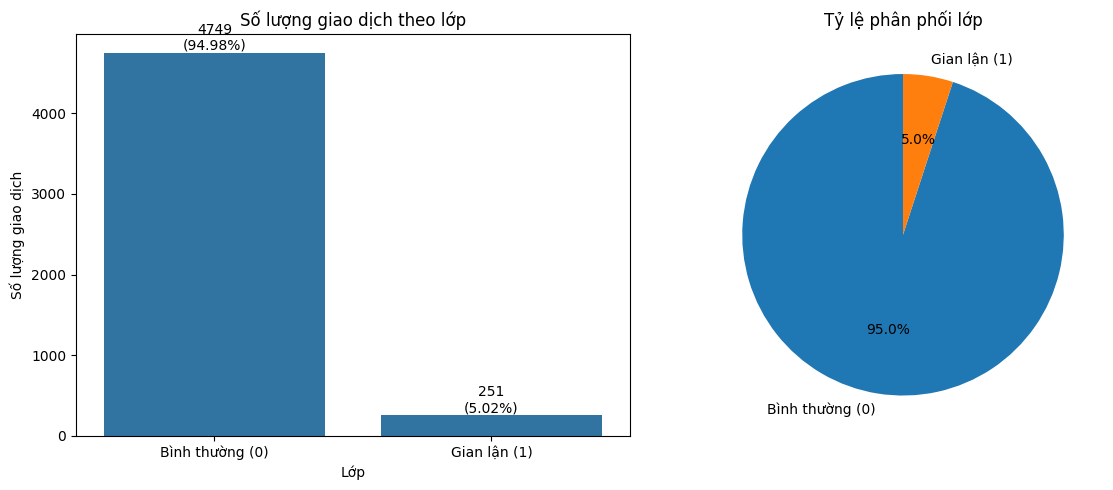

In [10]:
# 2.2. VISUALIZE TARGET DISTRIBUTION

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sns.barplot(
    data = target_summary,
    x = "Class",
    y = "Count",
    ax = axes[0]
)

axes[0].set_title("Số lượng giao dịch theo lớp")
axes[0].set_xlabel("Lớp")
axes[0].set_ylabel("Số lượng giao dịch")

for i, row in target_summary.iterrows():
    axes[0].text(
        i,
        row["Count"],
        f"{row['Count']}\n({row['Rate (%)']:.2f}%)",
        ha="center",
        va="bottom"
    )

# Pie chart
axes[1].pie(
    target_summary["Count"],
    labels=target_summary["Class"],
    autopct="%1.1f%%",
    startangle=90
)

axes[1].set_title("Tỷ lệ phân phối lớp")

plt.tight_layout()
plt.show()

Biểu đồ cột và biểu đồ tròn được dùng để trực quan hóa mức độ mất cân bằng giữa hai lớp của biến mục tiêu `Is_Fraudulent`.

Kết quả cho thấy lớp giao dịch bình thường chiếm phần lớn dữ liệu với 4749 mẫu, tương ứng 94.98%. Trong khi đó, lớp giao dịch gian lận chỉ có 251 mẫu, tương ứng 5.02%. Sự chênh lệch này cho thấy bộ dữ liệu bị mất cân bằng lớp rõ rệt.

Từ kết quả này, nếu chỉ dùng Accuracy để đánh giá mô hình thì có thể gây hiểu nhầm, vì mô hình dự đoán phần lớn là giao dịch bình thường vẫn có thể đạt Accuracy cao. Do đó, các bước huấn luyện và đánh giá phía sau cần ưu tiên các chỉ số phản ánh khả năng phát hiện fraud như `Recall`, `F2-score` và `PR-AUC`.


## 3. EDA: PHÂN TÍCH CÁC BIẾN SỐ (NUMERICAL FEATURES)

Mục tiêu của phần này là phân tích phân phối của các biến số và đánh giá khả năng phân biệt giữa giao dịch bình thường và giao dịch gian lận.

Các câu hỏi cần trả lời:

- Phân phối dữ liệu có bị lệch hay không?
- Có xuất hiện outlier hay không?
- Hai lớp fraud và non-fraud có khác nhau không?
- Biến nào có khả năng hỗ trợ mô hình phân loại?
- Có cần thực hiện log-transform hoặc tạo thêm feature mới hay không?

In [11]:
# 3.1 DESCRIPTIVE STATISTICS

num_features = [
    'Transaction_Amount',
    'Transaction_Frequency',
    'Average_Transaction_Amount',
    'Time_Since_Last_Transaction',
    'Deviation_From_Avg'
]

display(
    df[num_features].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Transaction_Amount,5000.0000,2484.6631,1447.8786,1.0600,1220.0675,2500.5450,3740.7575,4998.5900
Transaction_Frequency,5000.0000,25.2532,14.1052,1.0000,13.0000,25.0000,37.0000,49.0000
Average_Transaction_Amount,5000.0000,1045.0249,563.7922,50.0900,563.8900,1048.8750,1530.6050,1999.8100
Time_Since_Last_Transaction,5000.0000,50.3070,28.5761,1.0000,26.0000,50.0000,76.0000,99.0000
Deviation_From_Avg,5000.0000,1439.6382,1551.8811,-1940.8100,178.2875,1459.5100,2701.5000,4895.0600


Bảng thống kê mô tả được sử dụng để kiểm tra nhanh phạm vi giá trị, trung bình, trung vị và mức độ phân tán của các biến số. Đây là bước cần thiết trước khi trực quan hóa sâu hơn, vì nó giúp nhận diện sơ bộ các biến có miền giá trị rộng, khả năng lệch phân phối hoặc có giá trị bất thường.

Kết quả cho thấy các biến số đều có đủ 5000 quan sát. Với `Transaction_Amount`, giá trị dao động từ 1.06 đến 4998.59, trung vị khoảng 2500.55 và trung bình khoảng 2484.66. `Transaction_Frequency` có giá trị từ 1 đến 49, trung vị là 25. Các biến `Average_Transaction_Amount` và `Time_Since_Last_Transaction` cũng có trung bình và trung vị khá gần nhau. Điều này cho thấy các biến này chưa có dấu hiệu lệch phân phối quá mạnh khi quan sát ở mức thống kê tổng quát.

Riêng `Deviation_From_Avg` có miền giá trị rộng hơn, từ -1940.81 đến 4895.06, phản ánh mức chênh lệch giữa giao dịch hiện tại và giá trị giao dịch trung bình. Biến này có thể mang thông tin về mức độ bất thường của giao dịch, nhưng cần phân tích thêm bằng biểu đồ phân phối, skewness/kurtosis và so sánh theo nhãn để đánh giá rõ hơn.

Từ kết quả này, bước tiếp theo cần tiếp tục kiểm tra phân phối của các biến số bằng histogram, skewness/kurtosis và boxplot theo target. Các kết quả đó sẽ là cơ sở để quyết định có cần tạo log features, dùng RobustScaler hoặc tạo thêm các đặc trưng tương tác ở phần tiền xử lý sau khi chia tập.


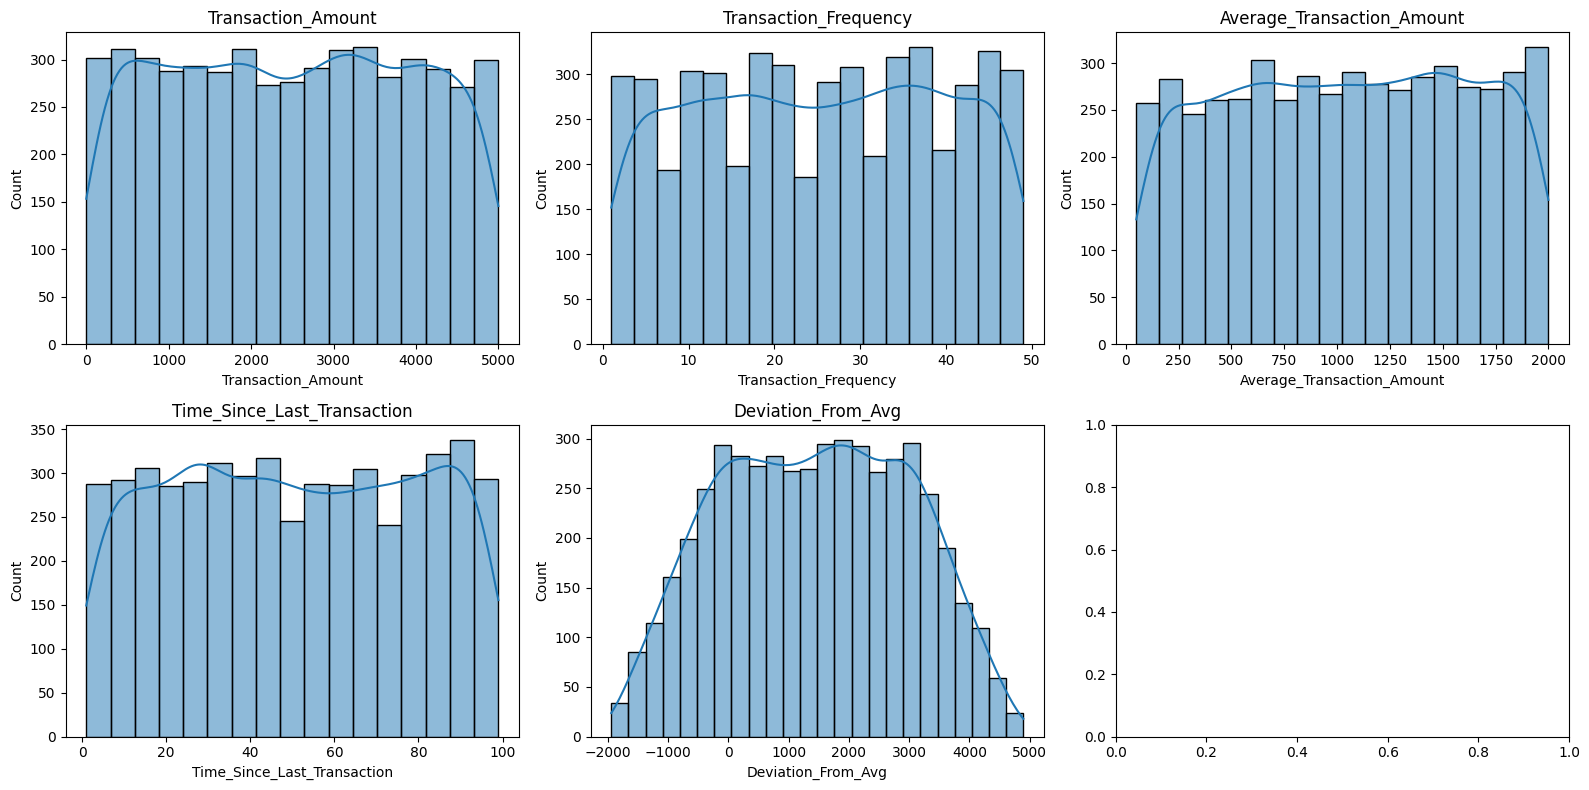

In [12]:
# 3.2. Histogram và Skewness Check
# ---------------------------------------------
# 3.2.1. DISTRIBUTION OF NUMERICAL FEATURES

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Các histogram được sử dụng để quan sát hình dạng phân phối của từng biến số. Bước này giúp kiểm tra dữ liệu có bị lệch mạnh hay không, từ đó làm cơ sở cho các quyết định xử lý như log-transform, scaling hoặc tạo thêm đặc trưng ở các bước sau.

Kết quả cho thấy `Transaction_Amount`, `Transaction_Frequency`, `Average_Transaction_Amount` và `Time_Since_Last_Transaction` có phân phối tương đối trải đều trên miền giá trị, chưa thể hiện xu hướng lệch phải hoặc lệch trái rõ rệt. Biến `Deviation_From_Avg` có dạng phân phối tập trung hơn ở vùng giữa và giảm dần về hai phía, nhưng vẫn chưa cho thấy lệch phân phối quá mạnh.

Từ kết quả này, log-transform không phải là bước bắt buộc để xử lý skewness cho toàn bộ biến số. Tuy nhiên, các biến log vẫn có thể được tạo thêm ở bước Feature Engineering như một cách biểu diễn bổ sung. Ngoài ra, do các biến có thang đo khác nhau, bước scaling vẫn cần được thực hiện sau khi chia tập dữ liệu để hỗ trợ quá trình huấn luyện mô hình.


In [13]:
# 3.2. Histogram và Skewness Check
# -----------------------------------------------------
# 3.2.2. SKEWNESS CHECK - KIỂM TRA ĐỘ LỆCH PHÂN PHỐI

skew_report = pd.DataFrame({
    "Feature": num_features,
    "Mean": [df[col].mean() for col in num_features],
    "Median": [df[col].median() for col in num_features],
    "Skewness": [df[col].skew() for col in num_features]
})

def skew_interpretation(skew):
    if skew > 1:
        return "Lệch phải mạnh"
    elif skew > 0.5:
        return "Lệch phải vừa"
    elif skew < -1:
        return "Lệch trái mạnh"
    elif skew < -0.5:
        return "Lệch trái vừa"
    else:
        return "Gần đối xứng"

skew_report["Interpretation"] = skew_report["Skewness"].apply(skew_interpretation)

display(skew_report.sort_values("Skewness", ascending=False))

,Feature,Mean,Median,Skewness,Interpretation
0,Transaction_Amount,2484.6631,2500.5450,0.0040,Gần đối xứng
3,Time_Since_Last_Transaction,50.3070,50.0000,0.0007,Gần đối xứng
4,Deviation_From_Avg,1439.6382,1459.5100,-0.0091,Gần đối xứng
1,Transaction_Frequency,25.2532,25.0000,-0.0243,Gần đối xứng
2,Average_Transaction_Amount,1045.0249,1048.8750,-0.0348,Gần đối xứng


Bảng skewness được sử dụng để kiểm tra mức độ lệch phân phối của các biến số. Chỉ số này giúp xác định liệu dữ liệu có bị lệch phải hoặc lệch trái rõ rệt hay không, từ đó cân nhắc việc sử dụng log-transform hoặc các bước xử lý phân phối khác.

Kết quả cho thấy skewness của tất cả các biến đều rất gần 0. Cụ thể, `Transaction_Amount`, `Time_Since_Last_Transaction`, `Deviation_From_Avg`, `Transaction_Frequency` và `Average_Transaction_Amount` đều được đánh giá là gần đối xứng. Điều này phù hợp với nhận xét từ histogram rằng các biến số không bị lệch phân phối mạnh.

Từ kết quả này, log-transform không phải là bước bắt buộc để xử lý skewness trong bộ dữ liệu này. Tuy nhiên, các biến log vẫn có thể được tạo thêm ở bước Feature Engineering như một dạng biểu diễn bổ sung để mô hình có thêm thông tin khi học quan hệ phi tuyến.


In [14]:
# 3.3. NUMERICAL EDA - SUMMARY STATISTICS

numeric_cols_raw = [
    "Transaction_Amount",
    "Transaction_Frequency",
    "Average_Transaction_Amount",
    "Time_Since_Last_Transaction",
    "Deviation_From_Avg"
]

numeric_summary = df[numeric_cols_raw].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

numeric_summary["skewness"] = df[numeric_cols_raw].skew()
numeric_summary["kurtosis"] = df[numeric_cols_raw].kurtosis()

display(numeric_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skewness,kurtosis
Transaction_Amount,5000.0000,2484.6631,1447.8786,1.0600,55.9621,252.1560,1220.0675,2500.5450,3740.7575,4752.7290,4947.5627,4998.5900,0.0040,-1.2089
Transaction_Frequency,5000.0000,25.2532,14.1052,1.0000,1.0000,3.0000,13.0000,25.0000,37.0000,47.0000,49.0000,49.0000,-0.0243,-1.2031
Average_Transaction_Amount,5000.0000,1045.0249,563.7922,50.0900,71.5571,155.3735,563.8900,1048.8750,1530.6050,1915.8585,1986.3758,1999.8100,-0.0348,-1.1910
Time_Since_Last_Transaction,5000.0000,50.3070,28.5761,1.0000,2.0000,6.0000,26.0000,50.0000,76.0000,94.0000,98.0000,99.0000,0.0007,-1.2200
Deviation_From_Avg,5000.0000,1439.6382,1551.8811,-1940.8100,-1588.4484,-1043.6325,178.2875,1459.5100,2701.5000,3920.1220,4487.5845,4895.0600,-0.0091,-0.9428


Bảng thống kê mở rộng được sử dụng để kiểm tra kỹ hơn phân phối của các biến số thông qua các mốc phân vị như 1%, 5%, 95% và 99%, đồng thời bổ sung thêm skewness và kurtosis. Bước này giúp đánh giá dữ liệu có bị lệch mạnh hay có vùng giá trị cực trị đáng chú ý hay không.

Kết quả cho thấy các biến số đều có đủ 5000 quan sát. `Transaction_Amount` dao động từ 1.06 đến 4998.59, với trung vị khoảng 2500.55. `Transaction_Frequency` dao động từ 1 đến 49, trung vị là 25. `Average_Transaction_Amount` nằm trong khoảng từ 50.09 đến 1999.81, còn `Time_Since_Last_Transaction` nằm trong khoảng từ 1 đến 99. Riêng `Deviation_From_Avg` có miền giá trị rộng hơn, từ -1940.81 đến 4895.06.

Skewness của tất cả các biến đều gần 0, ví dụ `Transaction_Amount` là 0.0040, `Time_Since_Last_Transaction` là 0.0007 và `Average_Transaction_Amount` là -0.0348. Điều này cho thấy các biến số không bị lệch phải hoặc lệch trái rõ rệt. Các giá trị kurtosis đều âm, cho thấy phân phối có xu hướng khá bẹt, không tập trung quá mạnh quanh trung tâm.

Từ kết quả này, log-transform không phải là bước bắt buộc để xử lý lệch phân phối. Tuy nhiên, một số biến có vùng giá trị cao đáng chú ý, ví dụ `Transaction_Amount` có Q95 khoảng 4752.73 và Q99 khoảng 4947.56, còn `Deviation_From_Avg` có Q95 khoảng 3920.12 và Q99 khoảng 4487.58. Vì vậy, ở các bước sau cần tiếp tục kiểm tra outlier và có thể tạo thêm các biến đánh dấu vùng cực trị Q95/Q99 trong Feature Engineering.


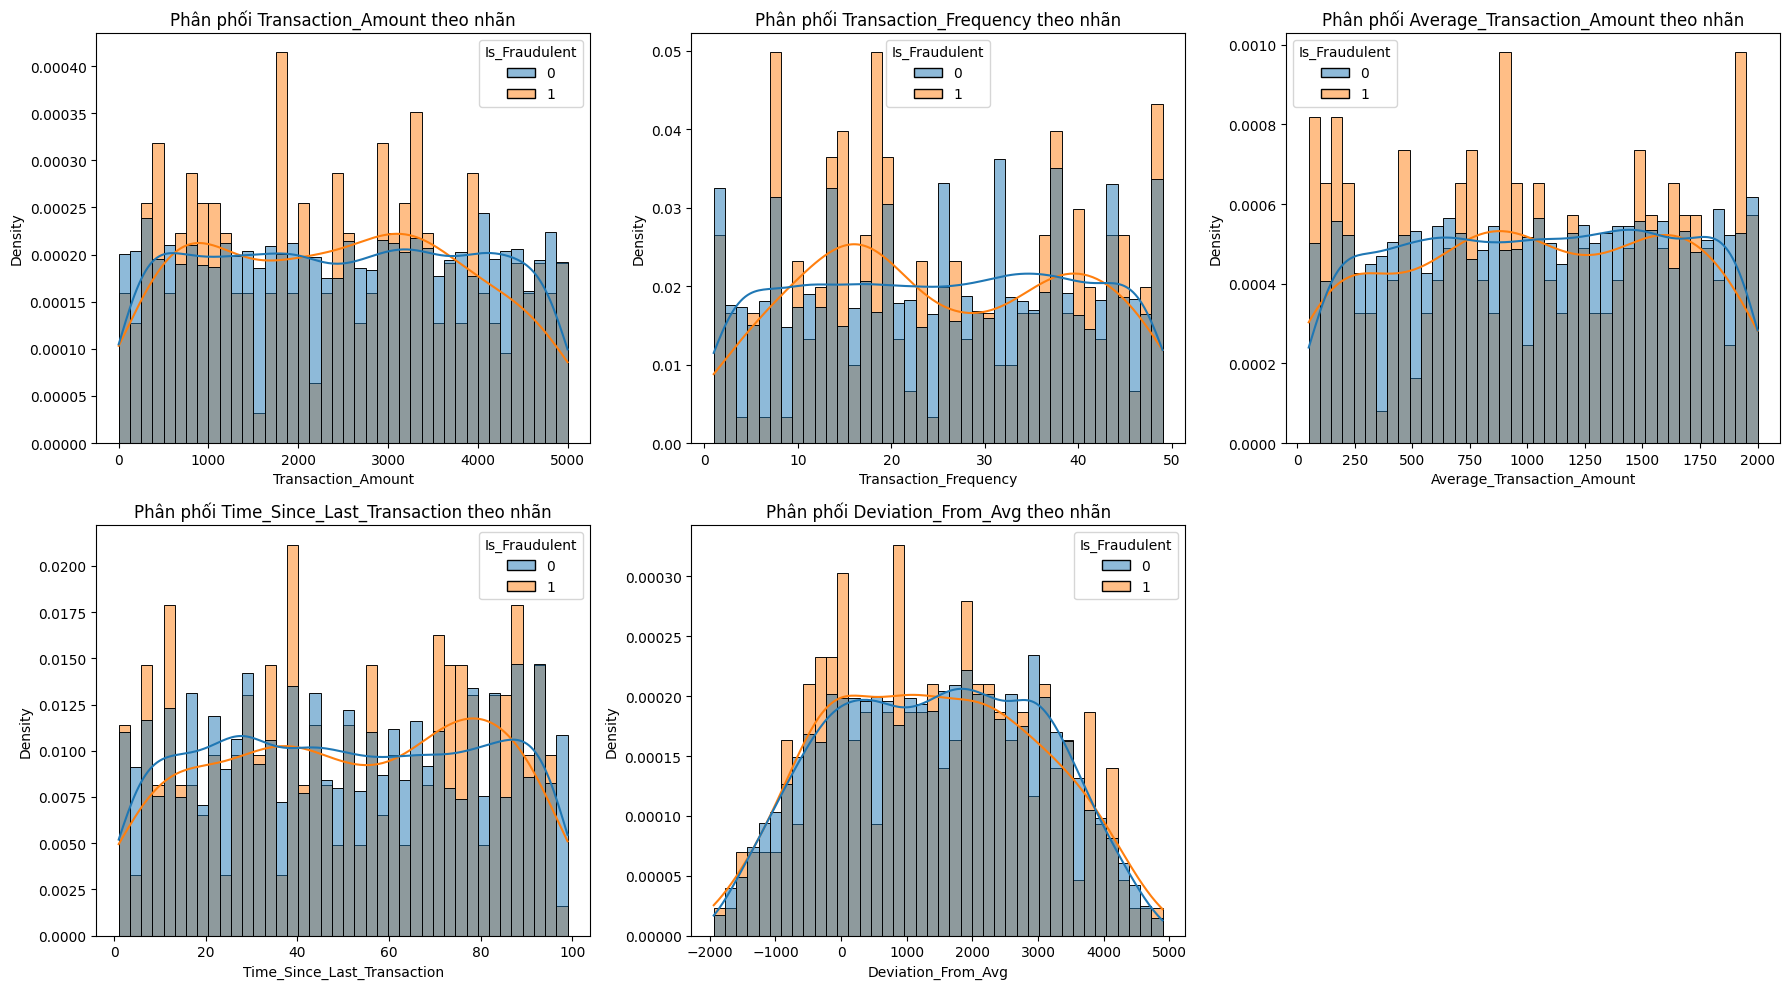

In [15]:
# 3.4. DISTRIBUTION OF NUMERICAL FEATURES BY TARGET

plt.figure(figsize=(18, 10))

for i, col in enumerate(numeric_cols_raw, 1):
    plt.subplot(2, 3, i)

    sns.histplot(
        data=df,
        x=col,
        hue="Is_Fraudulent",
        bins=40,
        kde=True,
        stat="density",
        common_norm=False
    )
    plt.title(f"Phân phối {col} theo nhãn")

plt.tight_layout()
plt.show()

Các biểu đồ phân phối theo nhãn được dùng để kiểm tra xem từng biến số có giúp phân biệt giao dịch bình thường và giao dịch gian lận hay không. Nếu hai lớp có phân phối khác biệt rõ, biến đó có thể mang tín hiệu tốt cho mô hình. Ngược lại, nếu hai phân phối chồng lấp nhiều, biến riêng lẻ chưa đủ mạnh để tách hai lớp.

Kết quả cho thấy các biến số có miền giá trị khá rộng, ví dụ `Transaction_Amount` trải từ khoảng 1 đến gần 5000, `Transaction_Frequency` từ 1 đến 49, `Average_Transaction_Amount` từ khoảng 50 đến gần 2000, `Time_Since_Last_Transaction` từ 1 đến 99 và `Deviation_From_Avg` từ khoảng -1940 đến 4895. Tuy nhiên, trên các biểu đồ, hai lớp `0` và `1` vẫn chồng lấp nhiều trên gần như toàn bộ miền giá trị.

Điều này cho thấy các biến số gốc khi xét riêng lẻ chưa tạo ra ranh giới phân tách rõ giữa giao dịch bình thường và giao dịch gian lận. Vì vậy, ở các bước sau, bài làm cần tạo thêm đặc trưng tương tác, đặc trưng tỷ lệ và đặc trưng hành vi để giúp mô hình khai thác quan hệ kết hợp giữa nhiều biến.


In [16]:
# 3.5. NUMERICAL COMPARISON BETWEEN NORMAL AND FRAUD

normal_stats = df[df["Is_Fraudulent"] == 0][numeric_cols_raw].agg(["mean", "median", "std"]).T
fraud_stats = df[df["Is_Fraudulent"] == 1][numeric_cols_raw].agg(["mean", "median", "std"]).T

num_compare = pd.DataFrame({
    "Normal_Mean": normal_stats["mean"],
    "Fraud_Mean": fraud_stats["mean"],
    "Mean_Diff": fraud_stats["mean"] - normal_stats["mean"],
    "Normal_Median": normal_stats["median"],
    "Fraud_Median": fraud_stats["median"],
    "Median_Diff": fraud_stats["median"] - normal_stats["median"],
    "Normal_Std": normal_stats["std"],
    "Fraud_Std": fraud_stats["std"]
})

display(num_compare)

,Normal_Mean,Fraud_Mean,Mean_Diff,Normal_Median,Fraud_Median,Median_Diff,Normal_Std,Fraud_Std
Transaction_Amount,2488.1642,2418.4218,-69.7424,2502.3000,2447.4700,-54.8300,1449.5514,1417.0567
Transaction_Frequency,25.2438,25.4303,0.1864,25.0000,23.0000,-2.0000,14.1097,14.0461
Average_Transaction_Amount,1045.6677,1032.8617,-12.8061,1052.4000,1027.0900,-25.3100,562.7436,584.3046
Time_Since_Last_Transaction,50.2516,51.3546,1.1029,50.0000,52.0000,2.0000,28.5896,28.3546
Deviation_From_Avg,1442.4964,1385.5601,-56.9363,1470.0300,1318.3100,-151.7200,1551.8337,1554.8879


Kết quả cho thấy chênh lệch giữa hai lớp nhìn chung không lớn. Với `Transaction_Amount`, giá trị trung bình của lớp bình thường là khoảng 2488.16, còn lớp gian lận là khoảng 2418.42, chênh lệch khoảng -69.74. Với `Average_Transaction_Amount`, trung bình của hai lớp lần lượt là 1045.67 và 1032.86, chênh lệch chỉ khoảng -12.81. `Transaction_Frequency` cũng khá gần nhau, với trung bình 25.24 ở lớp bình thường và 25.43 ở lớp gian lận.

Một số biến có khác biệt nhẹ ở median, ví dụ `Deviation_From_Avg` có median của lớp bình thường là 1470.03, trong khi lớp gian lận là 1318.31, chênh lệch khoảng -151.72. Tuy nhiên, độ lệch chuẩn của hai lớp ở hầu hết các biến vẫn khá lớn, cho thấy dữ liệu giữa hai nhóm còn chồng lấp nhiều.

Từ kết quả này, các biến số gốc khi xét riêng lẻ chưa đủ mạnh để phân tách rõ giao dịch bình thường và giao dịch gian lận. Vì vậy, ở các bước sau cần tạo thêm đặc trưng tương tác, đặc trưng tỷ lệ và đặc trưng hành vi để mô hình có thể khai thác quan hệ kết hợp giữa nhiều biến.


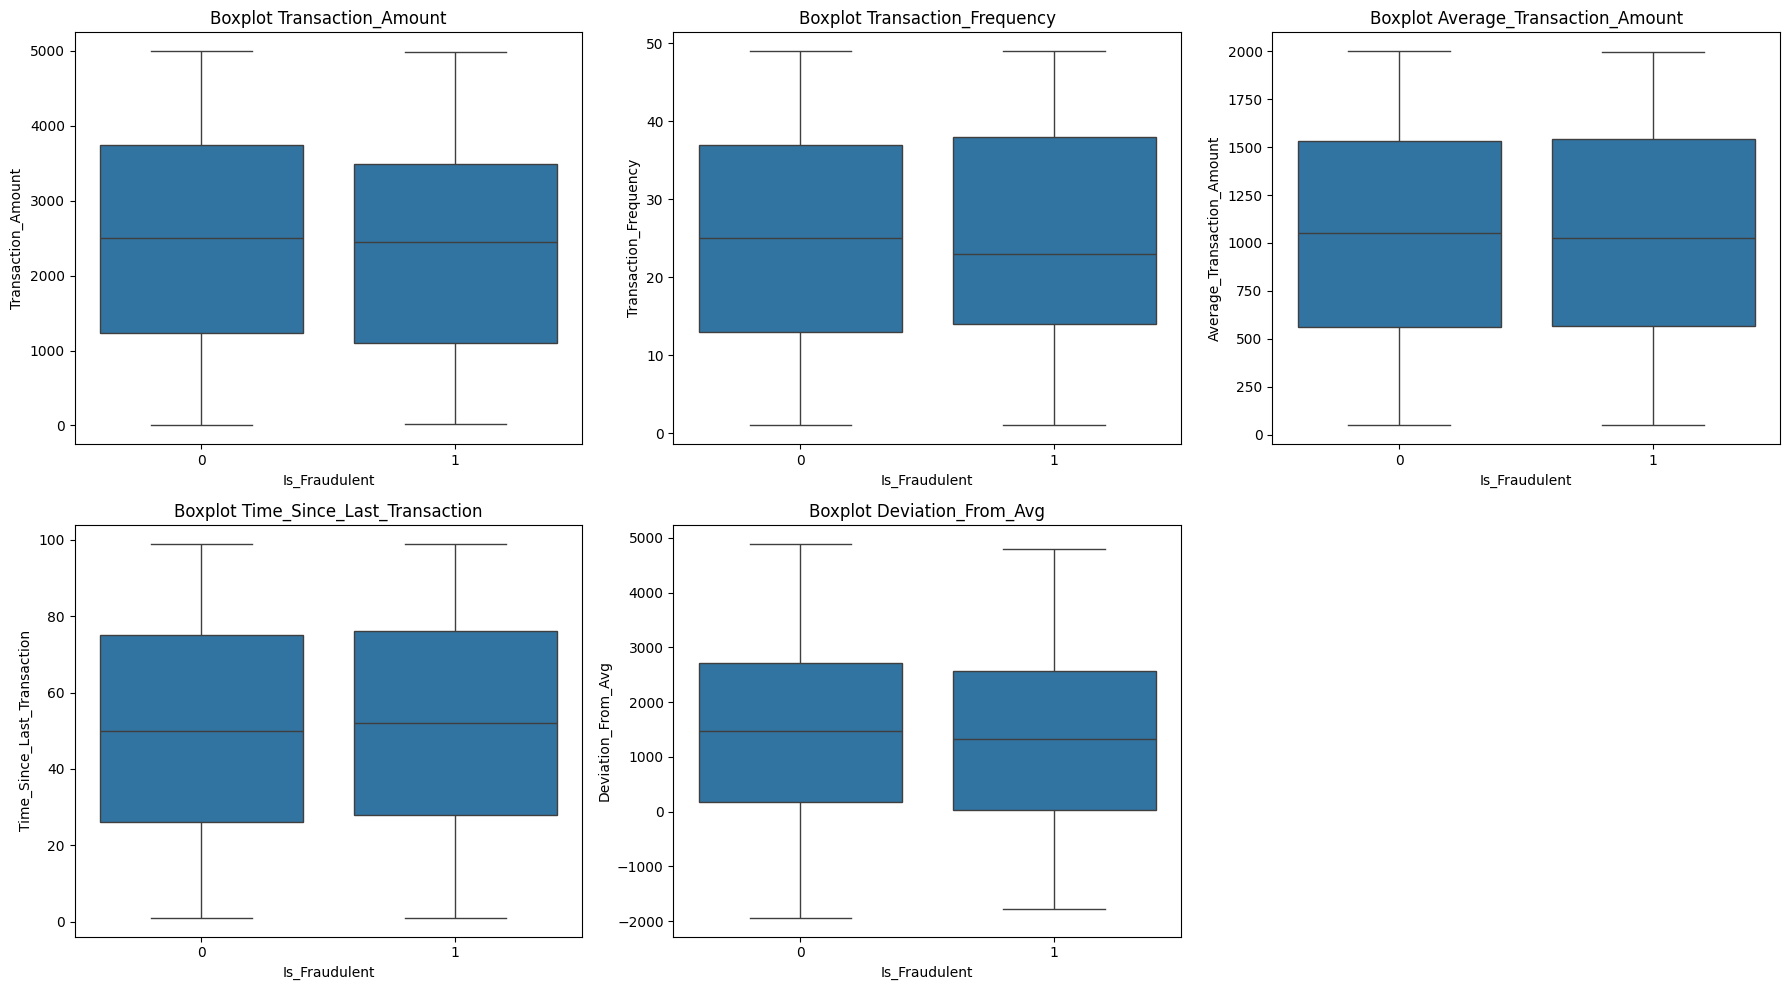

In [17]:
# 3.6. BOXPLOT OF NUMERICAL FEATURES BY TARGET

plt.figure(figsize=(18, 10))

for i, col in enumerate(numeric_cols_raw, 1):
    plt.subplot(2, 3, i)

    sns.boxplot(
        data=df,
        x="Is_Fraudulent",
        y=col
    )

    plt.title(f"Boxplot {col}")

plt.tight_layout()
plt.show()

Boxplot được sử dụng để so sánh trung vị, khoảng tứ phân vị và mức độ phân tán của các biến số giữa hai lớp giao dịch bình thường và giao dịch gian lận. Bước này giúp kiểm tra xem các biến số có tạo ra sự khác biệt rõ ràng giữa hai nhóm khi xét theo nhãn hay không.

Kết quả cho thấy median và khoảng phân tán của hai lớp khá gần nhau ở hầu hết các biến. Với `Transaction_Amount`, median của lớp bình thường khoảng 2502.30, còn lớp gian lận khoảng 2447.47. Với `Transaction_Frequency`, median lần lượt là 25 và 23. `Average_Transaction_Amount` cũng chỉ chênh nhẹ, với median khoảng 1052.40 ở lớp bình thường và 1027.09 ở lớp gian lận. `Time_Since_Last_Transaction` có median của lớp gian lận cao hơn nhẹ, 52 so với 50 ở lớp bình thường.

Riêng `Deviation_From_Avg` có chênh lệch median rõ hơn một chút, với lớp bình thường khoảng 1470.03 và lớp gian lận khoảng 1318.31. Tuy nhiên, hai boxplot vẫn chồng lấp nhiều và khoảng phân tán của hai lớp còn khá rộng.

Nhìn chung, các boxplot cho thấy các biến số gốc chưa tạo ra sự phân tách rõ ràng giữa giao dịch bình thường và giao dịch gian lận. Vì vậy, ở bước Feature Engineering cần tạo thêm các đặc trưng tương tác, đặc trưng tỷ lệ và đặc trưng hành vi để hỗ trợ mô hình khai thác mối quan hệ giữa nhiều biến thay vì chỉ dựa vào từng biến riêng lẻ.


In [18]:
# 3.7 STATISTICAL TEST — KIỂM TRA Ý NGHĨA THỐNG KÊ
# Mann-Whitney U test: không giả định phân phối chuẩn,
# phù hợp khi hai nhóm có kích thước chênh lệch lớn (4749 vs 251)

from scipy import stats

mw_rows = []

for col in numeric_cols_raw:
    g0 = df[df["Is_Fraudulent"] == 0][col]
    g1 = df[df["Is_Fraudulent"] == 1][col]

    stat, pval = stats.mannwhitneyu(g0, g1, alternative="two-sided")

    mw_rows.append({
        "Feature"      : col,
        "Mean_Normal"  : g0.mean(),
        "Mean_Fraud"   : g1.mean(),
        "Mean_Diff"    : g1.mean() - g0.mean(),
        "MW_Statistic" : stat,
        "p_value"      : pval,
        "Significant"  : "Có (p < 0.05)" if pval < 0.05 else "Không"
    })

mw_df = pd.DataFrame(mw_rows)

print("Bảng 3.7. Mann-Whitney U Test — So sánh phân phối fraud vs normal")
display(mw_df.round(4))

n_significant = (mw_df["p_value"] < 0.05).sum()
print(f"\nSố biến có sự khác biệt có ý nghĩa thống kê (p < 0.05): {n_significant}/{len(mw_df)}")

Bảng 3.7. Mann-Whitney U Test — So sánh phân phối fraud vs normal


,Feature,Mean_Normal,Mean_Fraud,Mean_Diff,MW_Statistic,p_value,Significant
0,Transaction_Amount,2488.1642,2418.4218,-69.7424,612534.0000,0.4582,Không
1,Transaction_Frequency,25.2438,25.4303,0.1864,590994.5000,0.8223,Không
2,Average_Transaction_Amount,1045.6677,1032.8617,-12.8061,603204.0000,0.7465,Không
3,Time_Since_Last_Transaction,50.2516,51.3546,1.1029,582941.5000,0.5580,Không
4,Deviation_From_Avg,1442.4964,1385.5601,-56.9363,609997.0000,0.5300,Không



Số biến có sự khác biệt có ý nghĩa thống kê (p < 0.05): 0/5


Kiểm định Mann-Whitney U được sử dụng để kiểm tra xem phân phối của từng biến số có khác nhau có ý nghĩa thống kê giữa lớp bình thường và lớp gian lận hay không. Khác với t-test, Mann-Whitney không yêu cầu giả định phân phối chuẩn và phù hợp khi hai nhóm có kích thước chênh lệch lớn như trường hợp này (4749 vs 251).

Kết quả cho thấy toàn bộ 5 biến số đều có p-value lớn hơn 0.05, cụ thể từ 0.4582 (`Transaction_Amount`) đến 0.8223 (`Transaction_Frequency`). Điều này có nghĩa là không có đủ bằng chứng thống kê để kết luận phân phối của bất kỳ biến số nào khác nhau giữa hai lớp. Kết quả này nhất quán với quan sát từ histogram và boxplot ở các bước trước, nơi hai lớp chồng lấp nhiều trên toàn bộ miền giá trị.

Đây là hạn chế thực sự của bộ dữ liệu: các biến số được cung cấp không mang tín hiệu phân biệt đủ mạnh ở cấp độ từng biến đơn lẻ. Vì vậy, bài làm cần dựa vào tổ hợp biến và interaction features ở bước Feature Engineering để cố gắng khai thác tín hiệu tiềm ẩn, thay vì kỳ vọng mô hình học được từ từng biến riêng lẻ.

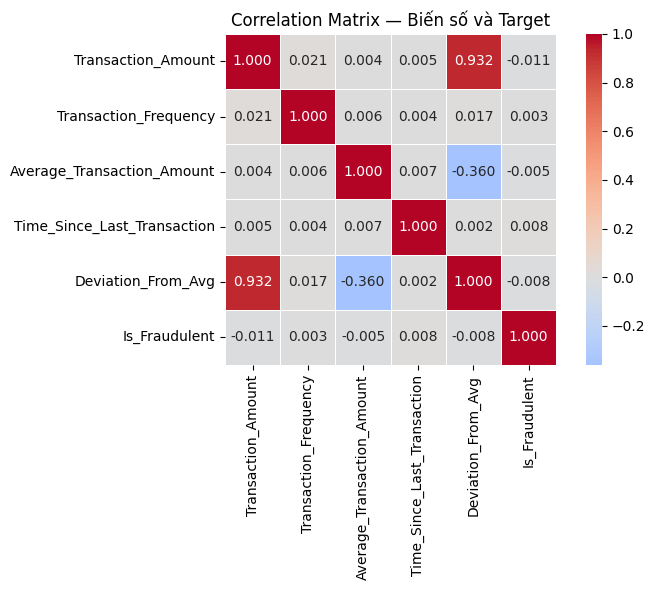

Correlation với Is_Fraudulent:


,Is_Fraudulent
Transaction_Amount,-0.0105
Time_Since_Last_Transaction,0.0084
Deviation_From_Avg,-0.0080
Average_Transaction_Amount,-0.0050
Transaction_Frequency,0.0029


In [19]:
# 3.8 CORRELATION HEATMAP

corr_cols = numeric_cols_raw + ["Is_Fraudulent"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix — Biến số và Target")
plt.tight_layout()
plt.show()

# In riêng correlation với target để dễ đọc
print("Correlation với Is_Fraudulent:")
display(
    corr_matrix["Is_Fraudulent"]
    .drop("Is_Fraudulent")
    .sort_values(key=abs, ascending=False)
    .to_frame()
    .round(4)
)

Correlation matrix được sử dụng để đánh giá đồng thời hai khía cạnh: mức độ tương quan giữa các biến số với nhau (multicollinearity) và mức độ tương quan của từng biến với target `Is_Fraudulent`.

Về multicollinearity, điểm đáng chú ý nhất là `Transaction_Amount` và `Deviation_From_Avg` có correlation 0.932 — rất cao. Điều này hợp lý vì đã xác nhận ở bước kiểm tra leakage rằng `Deviation_From_Avg = Transaction_Amount - Average_Transaction_Amount`, tức là `Deviation_From_Avg` phụ thuộc tuyến tính gần như hoàn toàn vào `Transaction_Amount`. Các cặp biến còn lại có correlation gần 0, cho thấy không có vấn đề multicollinearity bổ sung nào đáng lo ngại.
Về tương quan với target, toàn bộ 5 biến số đều có correlation với `Is_Fraudulent` cực kỳ thấp, dao động từ -0.011 đến 0.008. Không có biến nào mang tín hiệu tuyến tính rõ ràng với nhãn gian lận. Kết quả này nhất quán với Mann-Whitney test ở mục 3.7 và củng cố thêm nhận định rằng bộ dữ liệu không có tín hiệu phân biệt mạnh ở cấp độ từng biến đơn lẻ.

# 4. EDA: Phân tích biến phân loại

Bên cạnh các biến số, bộ dữ liệu còn chứa các biến phân loại như vị trí giao dịch (`Location`) và loại giao dịch (`Transaction_Type`).

Mục tiêu của phần này là:

- Khảo sát phân bố của từng nhóm category.
- So sánh tỷ lệ gian lận giữa các nhóm.
- Xác định xem có nhóm nào mang rủi ro cao hơn hay không.
- Tìm cơ sở cho các bước encoding và feature engineering phía sau.

In [20]:
# 4.1 CATEGORY DISTRIBUTION

cat_cols = [
    "Location",
    "Transaction_Type"
]

for col in cat_cols:

    print(f"\n{'='*50}")
    print(col)
    print('='*50)

    display(
        pd.DataFrame({
            "Count": df[col].value_counts(),
            "Rate_%": df[col].value_counts(normalize=True) * 100
        })
    )


Location


,Count,Rate_%
Location,,
City_B,1290,25.8000
City_A,1279,25.5800
City_C,1229,24.5800
City_D,1202,24.0400



Transaction_Type


,Count,Rate_%
Transaction_Type,,
Purchase,1704,34.0800
Transfer,1660,33.2000
Withdrawal,1636,32.7200


Bước này được thực hiện để kiểm tra phân bố số lượng mẫu trong các biến phân loại `Location` và `Transaction_Type`. Việc kiểm tra phân bố category giúp xác định xem có nhóm nào chiếm ưu thế quá lớn hoặc có nhóm nào quá ít mẫu hay không, từ đó làm cơ sở cho các bước phân tích fraud rate và mã hóa biến phân loại sau này.

Kết quả cho thấy biến `Location` có phân bố khá cân bằng giữa 4 thành phố. `City_B` có số lượng giao dịch cao nhất với 1290 mẫu, chiếm 25.80%, trong khi `City_D` thấp nhất với 1202 mẫu, chiếm 24.04%. Hai nhóm còn lại là `City_A` và `City_C` lần lượt chiếm 25.58% và 24.58%. Mức chênh lệch giữa các nhóm không lớn.

Với `Transaction_Type`, ba loại giao dịch cũng có tỷ lệ tương đối gần nhau. `Purchase` chiếm 34.08%, `Transfer` chiếm 33.20% và `Withdrawal` chiếm 32.72%. Điều này cho thấy dữ liệu không bị lệch mạnh về số lượng mẫu giữa các loại giao dịch.

Từ kết quả này, các biến phân loại không cần xử lý mất cân bằng theo nhóm category. Tuy nhiên, phân bố số lượng chỉ cho biết nhóm nào xuất hiện nhiều hay ít, chưa cho biết nhóm nào có rủi ro gian lận cao hơn. Vì vậy, bước tiếp theo cần phân tích fraud rate và Fraud Lift theo từng nhóm để đánh giá tín hiệu liên quan đến gian lận.


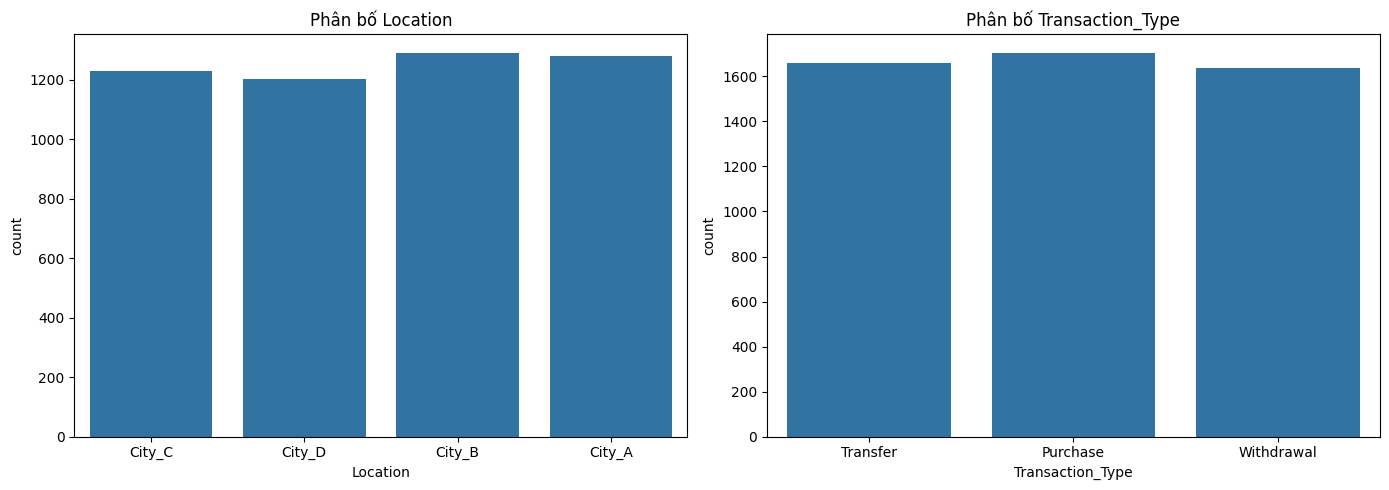

In [21]:
# 4.2 CATEGORY DISTRIBUTION PLOT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_cols):

    sns.countplot(
        data=df,
        x=col,
        ax=ax
    )

    ax.set_title(f'Phân bố {col}')

plt.tight_layout()
plt.show()

Kết quả cho thấy các nhóm trong biến `Location` có số lượng giao dịch tương đối gần nhau. `City_B` có số lượng cao nhất với 1290 giao dịch, còn `City_D` thấp nhất với 1202 giao dịch. Với `Transaction_Type`, số lượng giao dịch cũng không chênh lệch lớn: `Purchase` có 1704 giao dịch, `Transfer` có 1660 giao dịch và `Withdrawal` có 1636 giao dịch.

Như vậy, hai biến phân loại không bị mất cân bằng nghiêm trọng về số lượng mẫu giữa các nhóm. Tuy nhiên, biểu đồ này mới chỉ cho biết nhóm nào xuất hiện nhiều hay ít, chưa phản ánh nhóm nào có tỷ lệ gian lận cao hơn. Vì vậy, bước tiếp theo cần phân tích fraud rate và Fraud Lift theo từng nhóm để đánh giá mức độ liên quan của các biến phân loại với gian lận.


In [22]:
# 4.3 FRAUD RATE BY CATEGORY

for col in cat_cols:

    fraud_rate = (
        df.groupby(col)["Is_Fraudulent"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    fraud_rate.columns = [
        col,
        "Total",
        "Fraud_Count",
        "Fraud_Rate"
    ]

    fraud_rate["Fraud_Rate"] *= 100

    print(f"\n{col}")
    display(
        fraud_rate.sort_values(
            "Fraud_Rate",
            ascending=False
        )
    )


Location


,Location,Total,Fraud_Count,Fraud_Rate
3,City_D,1202,66,5.4908
0,City_A,1279,64,5.0039
1,City_B,1290,63,4.8837
2,City_C,1229,58,4.7193



Transaction_Type


,Transaction_Type,Total,Fraud_Count,Fraud_Rate
1,Transfer,1660,89,5.3614
2,Withdrawal,1636,81,4.9511
0,Purchase,1704,81,4.7535


Với biến `Location`, `City_D` có fraud rate cao nhất với 5.49%, tương ứng 66 giao dịch gian lận trên tổng 1202 giao dịch. Ngược lại, `City_C` có fraud rate thấp nhất với 4.72%, tương ứng 58 giao dịch gian lận trên tổng 1229 giao dịch. Các nhóm `City_A` và `City_B` lần lượt có fraud rate là 5.00% và 4.88%.

Với biến `Transaction_Type`, nhóm `Transfer` có fraud rate cao nhất với 5.36%, tương ứng 89 giao dịch gian lận trên tổng 1660 giao dịch. Hai nhóm còn lại là `Withdrawal` và `Purchase` có fraud rate lần lượt là 4.95% và 4.75%.

Nhìn chung, fraud rate giữa các nhóm có chênh lệch nhưng không quá lớn. Điều này cho thấy `Location` và `Transaction_Type` có thể chứa một phần tín hiệu liên quan đến gian lận, nhưng chưa đủ để kết luận nhóm nào là yếu tố quyết định fraud. Vì vậy, ở bước tiếp theo cần tiếp tục phân tích Fraud Lift để so sánh từng nhóm với tỷ lệ fraud trung bình của toàn bộ dữ liệu.


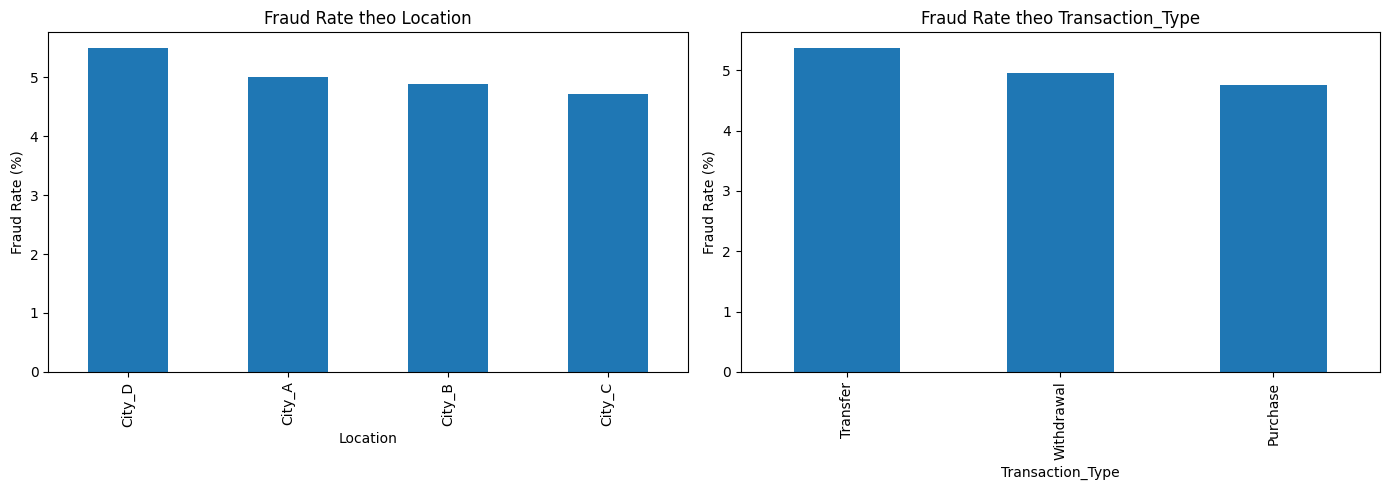

In [23]:
# 4.4 FRAUD RATE VISUALIZATION

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

for ax, col in zip(axes, cat_cols):

    fraud_rate = (
        df.groupby(col)["Is_Fraudulent"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    fraud_rate.plot(
        kind="bar",
        ax=ax
    )

    ax.set_ylabel("Fraud Rate (%)")
    ax.set_title(f"Fraud Rate theo {col}")

plt.tight_layout()
plt.show()

Biểu đồ được sử dụng để trực quan hóa tỷ lệ gian lận của từng nhóm trong hai biến phân loại `Location` và `Transaction_Type`. Bước này giúp quan sát nhanh nhóm nào có fraud rate cao hơn hoặc thấp hơn, thay vì chỉ nhìn vào bảng số liệu.

Với `Location`, `City_D` có fraud rate cao nhất, khoảng 5.49%, trong khi `City_C` thấp nhất, khoảng 4.72%. Hai nhóm còn lại là `City_A` và `City_B` có fraud rate lần lượt khoảng 5.00% và 4.88%. Như vậy, tỷ lệ gian lận giữa các thành phố có chênh lệch nhẹ, nhưng không quá lớn.

Với `Transaction_Type`, nhóm `Transfer` có fraud rate cao nhất, khoảng 5.36%. Hai nhóm `Withdrawal` và `Purchase` có fraud rate thấp hơn, lần lượt khoảng 4.95% và 4.75%.

Kết quả này cho thấy các biến phân loại có thể mang một phần tín hiệu liên quan đến gian lận, nhưng mức độ phân tách chưa mạnh. Vì vậy, các biến này nên được giữ lại và mã hóa ở bước tiền xử lý, đồng thời cần phân tích thêm Fraud Lift để so sánh từng nhóm với tỷ lệ fraud trung bình toàn bộ dữ liệu.


In [24]:
# 4.5 FRAUD LIFT

base_fraud_rate = df["Is_Fraudulent"].mean()

for col in cat_cols:

    fraud_lift = (
        df.groupby(col)["Is_Fraudulent"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    fraud_lift.columns = [
        col,
        "Total",
        "Fraud_Count",
        "Fraud_Rate"
    ]

    fraud_lift["Base_Fraud_Rate"] = base_fraud_rate
    fraud_lift["Lift"] = fraud_lift["Fraud_Rate"] / base_fraud_rate
    fraud_lift["Fraud_Rate_%"] = fraud_lift["Fraud_Rate"] * 100

    fraud_lift = fraud_lift.sort_values("Lift", ascending=False)

    print(f"\nFraud Lift theo {col}")
    display(
        fraud_lift[
            [col, "Total", "Fraud_Count", "Fraud_Rate_%", "Lift"]
        ]
    )


Fraud Lift theo Location


,Location,Total,Fraud_Count,Fraud_Rate_%,Lift
3,City_D,1202,66,5.4908,1.0938
0,City_A,1279,64,5.0039,0.9968
1,City_B,1290,63,4.8837,0.9729
2,City_C,1229,58,4.7193,0.9401



Fraud Lift theo Transaction_Type


,Transaction_Type,Total,Fraud_Count,Fraud_Rate_%,Lift
1,Transfer,1660,89,5.3614,1.0680
2,Withdrawal,1636,81,4.9511,0.9863
0,Purchase,1704,81,4.7535,0.9469


Fraud Lift được sử dụng để so sánh fraud rate của từng nhóm với fraud rate trung bình của toàn bộ dữ liệu. Nếu Lift lớn hơn 1, nhóm đó có tỷ lệ gian lận cao hơn mức trung bình; nếu Lift nhỏ hơn 1, nhóm đó có tỷ lệ gian lận thấp hơn mức trung bình.

Với biến `Location`, `City_D` có fraud rate cao nhất là 5.49% và Lift = 1.0938, tức là cao hơn mức trung bình chung khoảng 9.38%. Ngược lại, `City_C` có fraud rate thấp nhất là 4.72% và Lift = 0.9401. Hai nhóm `City_A` và `City_B` có Lift lần lượt là 0.9968 và 0.9729, gần với mức trung bình.

Với biến `Transaction_Type`, nhóm `Transfer` có fraud rate cao nhất là 5.36% và Lift = 1.0680, cao hơn mức trung bình khoảng 6.80%. Hai nhóm `Withdrawal` và `Purchase` có Lift lần lượt là 0.9863 và 0.9469, thấp hơn hoặc gần mức trung bình.

Nhìn chung, một số nhóm như `City_D` và `Transfer` có Lift lớn hơn 1, nhưng mức chênh lệch không quá lớn. Vì vậy, chưa thể xem các nhóm này là yếu tố quyết định gian lận. Tuy nhiên, các biến phân loại vẫn có một phần tín hiệu nên sẽ được giữ lại và mã hóa bằng One-Hot Encoding ở bước tiền xử lý.

In [25]:
# 4.6 STATISTICAL TEST — CHI-SQUARE TEST CHO BIẾN PHÂN LOẠI

chi2_rows = []

for col in cat_cols:
    ct = pd.crosstab(df[col], df["Is_Fraudulent"])
    chi2, pval, dof, _ = stats.chi2_contingency(ct)

    chi2_rows.append({
        "Feature"    : col,
        "Chi2_Stat"  : chi2,
        "p_value"    : pval,
        "DOF"        : dof,
        "Significant": "Có (p < 0.05)" if pval < 0.05 else "Không"
    })

chi2_df = pd.DataFrame(chi2_rows)

print("Bảng 4.6. Chi-Square Test — Kiểm tra độc lập giữa biến phân loại và Is_Fraudulent")
display(chi2_df.round(4))

Bảng 4.6. Chi-Square Test — Kiểm tra độc lập giữa biến phân loại và Is_Fraudulent


,Feature,Chi2_Stat,p_value,DOF,Significant
0,Location,0.8429,0.8392,3,Không
1,Transaction_Type,0.6760,0.7132,2,Không


Chi-square test được sử dụng để kiểm tra xem phân phối của biến phân loại có độc lập với nhãn `Is_Fraudulent`hay không. Nếu p-value nhỏ hơn 0.05, có thể kết luận biến phân loại đó có liên quan thống kê với khả năng gian lận.

Kết quả cho thấy cả `Location` (p = 0.8392) và `Transaction_Type` (p = 0.7132) đều không có ý nghĩa thống kê. Điều này cho thấy tỷ lệ gian lận giữa các nhóm city hay loại giao dịch chênh lệch không đủ lớn để vượt ngưỡng thống kê — nhất quán với Fraud Lift dao động rất hẹp quanh 1.0 đã quan sát ở mục 4.5.

Kết hợp với kết quả Mann-Whitney ở mục 3.7, có thể kết luận rằng bộ dữ liệu này không có biến nào — cả số lẫn phân loại — phân biệt được fraud và normal một cách có ý nghĩa thống kê khi xét đơn lẻ. Đây là cơ sở để hiểu tại sao các mô hình ở các bước sau có PR-AUC thấp, và cũng là lý do bài làm cần ghi nhận giới hạn của dữ liệu trong phần kết luận.

# 5. EDA: PHÂN TÍCH OUTLIER

Ở phần này, bài làm phân tích outlier trên các biến số để kiểm tra liệu các giá trị bất thường có liên quan đến giao dịch gian lận hay không.

Trong bài toán fraud detection, outlier không nên bị xóa một cách máy móc, vì các giao dịch bất thường về số tiền, tần suất hoặc độ lệch hành vi có thể chính là dấu hiệu gian lận. Do đó, mục tiêu của phần này là kiểm tra outlier, so sánh fraud rate trong nhóm bất thường và đưa ra quyết định xử lý phù hợp ở bước tiền xử lý.


In [26]:
# 5.1 IQR OUTLIER CHECK

numeric_cols_raw = [
    "Transaction_Amount",
    "Transaction_Frequency",
    "Average_Transaction_Amount",
    "Time_Since_Last_Transaction",
    "Deviation_From_Avg"
]

iqr_rows = []

for col in numeric_cols_raw:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)

    iqr_rows.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_mask.sum(),
        "Outlier_Rate_%": outlier_mask.mean() * 100
    })

iqr_summary = pd.DataFrame(iqr_rows)

print("Bảng 5.1. Kiểm tra outlier theo quy tắc IQR")
display(iqr_summary)

Bảng 5.1. Kiểm tra outlier theo quy tắc IQR


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Rate_%
0,Transaction_Amount,1220.0675,3740.7575,2520.6900,-2560.9675,7521.7925,0,0.0000
1,Transaction_Frequency,13.0000,37.0000,24.0000,-23.0000,73.0000,0,0.0000
2,Average_Transaction_Amount,563.8900,1530.6050,966.7150,-886.1825,2980.6775,0,0.0000
3,Time_Since_Last_Transaction,26.0000,76.0000,50.0000,-49.0000,151.0000,0,0.0000
4,Deviation_From_Avg,178.2875,2701.5000,2523.2125,-3606.5313,6486.3188,0,0.0000


Bước này được thực hiện để kiểm tra các giá trị ngoại lệ của các biến số theo quy tắc IQR. Quy tắc này xác định outlier dựa trên khoảng tứ phân vị, với ngưỡng dưới là `Q1 - 1.5 * IQR` và ngưỡng trên là `Q3 + 1.5 * IQR`.

Kết quả cho thấy cả 5 biến số đều có `Outlier_Count = 0` và `Outlier_Rate_% = 0.0000`. Ví dụ, với `Transaction_Amount`, ngưỡng dưới là -2560.97 và ngưỡng trên là 7521.79, trong khi giá trị thực tế của biến này nằm trong khoảng từ 1.06 đến 4998.59. Tương tự, `Deviation_From_Avg` có ngưỡng dưới -3606.53 và ngưỡng trên 6486.32, rộng hơn miền giá trị thực tế từ -1940.81 đến 4895.06.

Điều này cho thấy dữ liệu không có outlier rõ ràng theo quy tắc IQR. Vì vậy, bài làm không thực hiện xóa outlier ở bước này. Tuy nhiên, trong bài toán phát hiện gian lận, các giá trị nằm ở vùng cao như Q95 hoặc Q99 vẫn có thể mang tín hiệu bất thường, nên phần sau sẽ tiếp tục kiểm tra các vùng cực trị thay vì loại bỏ dữ liệu.


In [27]:
# 5.2 FRAUD RATE IN IQR OUTLIER GROUPS

df_outlier = df.copy()

for col in numeric_cols_raw:
    q1 = df_outlier[col].quantile(0.25)
    q3 = df_outlier[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    flag_col = f"{col}_IQR_Outlier"

    df_outlier[flag_col] = (
        (df_outlier[col] < lower_bound) |
        (df_outlier[col] > upper_bound)
    ).astype(int)


iqr_flag_cols = [f"{col}_IQR_Outlier" for col in numeric_cols_raw]

df_outlier["Any_IQR_Outlier"] = (
    df_outlier[iqr_flag_cols].sum(axis=1) > 0
).astype(int)


def summarize_flag_fraud_rate(data, flag_col):
    summary = (
        data
        .groupby(flag_col)["Is_Fraudulent"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    summary.columns = [
        flag_col,
        "Total",
        "Fraud_Count",
        "Fraud_Rate"
    ]

    summary["Fraud_Rate_%"] = summary["Fraud_Rate"] * 100
    summary["Lift"] = summary["Fraud_Rate"] / data["Is_Fraudulent"].mean()

    return summary


any_iqr_summary = summarize_flag_fraud_rate(
    df_outlier,
    "Any_IQR_Outlier"
)

print("Bảng 6.2. Fraud rate theo nhóm có/không có IQR outlier")
display(any_iqr_summary)

Bảng 6.2. Fraud rate theo nhóm có/không có IQR outlier


,Any_IQR_Outlier,Total,Fraud_Count,Fraud_Rate,Fraud_Rate_%,Lift
0,0,5000,251,0.0502,5.0200,1.0000


Bảng này được sử dụng để kiểm tra xem nhóm giao dịch có outlier theo quy tắc IQR có tỷ lệ gian lận khác với nhóm không có outlier hay không. Đây là bước bổ sung sau khi đã xác định outlier bằng IQR, nhằm đánh giá liệu outlier có liên quan đến nhãn `Is_Fraudulent` hay không.

Kết quả cho thấy toàn bộ 5000 giao dịch đều thuộc nhóm `Any_IQR_Outlier = 0`, tức là không có giao dịch nào bị đánh dấu là outlier theo quy tắc IQR. Trong nhóm này có 251 giao dịch gian lận, tương ứng fraud rate 5.02% và Lift = 1.0000, đúng bằng tỷ lệ gian lận trung bình của toàn bộ dữ liệu.

Do không tồn tại nhóm `Any_IQR_Outlier = 1`, không thể so sánh fraud rate giữa nhóm có outlier và nhóm không có outlier. Vì vậy, bài làm không xóa dữ liệu theo IQR và cũng không tạo cờ IQR outlier cho mô hình.

Tuy nhiên, trong bài toán phát hiện gian lận, các giá trị nằm ở vùng rất cao vẫn có thể mang tín hiệu bất thường dù không bị xem là outlier theo IQR. Vì vậy, bước tiếp theo sẽ tiếp tục phân tích các ngưỡng cực trị như Q95 và Q99 để tạo các biến đánh dấu phù hợp hơn.


In [28]:
#5.3 EXTREME VALUE CHECK BY Q95 AND Q99

tail_rows = []

base_fraud_rate = df["Is_Fraudulent"].mean()

for col in numeric_cols_raw:
    q95 = df[col].quantile(0.95)
    q99 = df[col].quantile(0.99)

    for q_name, threshold in [("Q95", q95), ("Q99", q99)]:
        flag = (df[col] >= threshold).astype(int)

        total_extreme = flag.sum()
        fraud_count_extreme = df.loc[flag == 1, "Is_Fraudulent"].sum()

        if total_extreme > 0:
            fraud_rate_extreme = df.loc[flag == 1, "Is_Fraudulent"].mean()
        else:
            fraud_rate_extreme = np.nan

        tail_rows.append({
            "Feature": col,
            "Threshold_Type": q_name,
            "Threshold_Value": threshold,
            "Extreme_Count": total_extreme,
            "Extreme_Rate_%": total_extreme / len(df) * 100,
            "Fraud_Count": fraud_count_extreme,
            "Fraud_Rate_%": fraud_rate_extreme * 100,
            "Lift": fraud_rate_extreme / base_fraud_rate
        })

tail_summary = pd.DataFrame(tail_rows)

print("Bảng 6.3. Fraud rate trong nhóm giá trị cực trị Q95/Q99")
display(tail_summary)

Bảng 6.3. Fraud rate trong nhóm giá trị cực trị Q95/Q99


,Feature,Threshold_Type,Threshold_Value,Extreme_Count,Extreme_Rate_%,Fraud_Count,Fraud_Rate_%,Lift
0,Transaction_Amount,Q95,4752.7290,250,5.0000,11,4.4000,0.8765
1,Transaction_Amount,Q99,4947.5627,50,1.0000,4,8.0000,1.5936
2,Transaction_Frequency,Q95,47.0000,305,6.1000,19,6.2295,1.2409
3,Transaction_Frequency,Q99,49.0000,91,1.8200,4,4.3956,0.8756
4,Average_Transaction_Amount,Q95,1915.8585,250,5.0000,17,6.8000,1.3546
5,Average_Transaction_Amount,Q99,1986.3758,50,1.0000,1,2.0000,0.3984
6,Time_Since_Last_Transaction,Q95,94.0000,293,5.8600,11,3.7543,0.7479
7,Time_Since_Last_Transaction,Q99,98.0000,88,1.7600,1,1.1364,0.2264
8,Deviation_From_Avg,Q95,3920.1220,250,5.0000,15,6.0000,1.1952
9,Deviation_From_Avg,Q99,4487.5845,50,1.0000,3,6.0000,1.1952


Kết quả cho thấy một số nhóm cực trị có fraud rate cao hơn mức trung bình toàn bộ dữ liệu là 5.02%. Cụ thể, `Transaction_Amount` tại ngưỡng Q99 có 50 giao dịch, trong đó có 4 giao dịch gian lận, tương ứng fraud rate 8.00% và Lift = 1.5936. `Average_Transaction_Amount` tại Q95 có fraud rate 6.80% với Lift = 1.3546. `Transaction_Frequency` tại Q95 cũng có fraud rate 6.23% với Lift = 1.2409. Ngoài ra, `Deviation_From_Avg` tại Q95 và Q99 đều có fraud rate 6.00%, cao hơn mức trung bình.

Tuy nhiên, không phải mọi nhóm cực trị đều có fraud rate cao hơn. Ví dụ, `Time_Since_Last_Transaction` tại Q99 chỉ có fraud rate 1.14% và `Average_Transaction_Amount` tại Q99 chỉ có fraud rate 2.00%. Điều này cho thấy không thể kết luận rằng mọi giá trị cực trị đều liên quan đến gian lận.

Từ kết quả này, bài làm không xóa các giá trị cực trị, mà sẽ tạo thêm các biến đánh dấu Q95/Q99 ở bước Feature Engineering. Các biến này giúp mô hình nhận biết giao dịch có nằm trong vùng giá trị cao bất thường hay không, đồng thời vẫn giữ nguyên dữ liệu gốc để tránh mất thông tin.


In [29]:
# 5.4 VISUALIZE IQR OUTLIER RATE


print("Bảng 6.4. Tỷ lệ outlier theo quy tắc IQR")
display(iqr_summary[["Feature", "Outlier_Count", "Outlier_Rate_%"]])

if iqr_summary["Outlier_Count"].sum() == 0:
    print("\nKhông phát hiện outlier theo quy tắc IQR ở các biến số đang xét.")
    print("Vì vậy, không cần vẽ biểu đồ outlier rate vì tất cả tỷ lệ đều bằng 0%.")
else:
    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=iqr_summary,
        x="Feature",
        y="Outlier_Rate_%"
    )

    plt.title("Outlier Rate theo quy tắc IQR")
    plt.xlabel("Feature")
    plt.ylabel("Outlier Rate (%)")
    plt.xticks(rotation=30)
    plt.show()

Bảng 6.4. Tỷ lệ outlier theo quy tắc IQR


,Feature,Outlier_Count,Outlier_Rate_%
0,Transaction_Amount,0,0.0000
1,Transaction_Frequency,0,0.0000
2,Average_Transaction_Amount,0,0.0000
3,Time_Since_Last_Transaction,0,0.0000
4,Deviation_From_Avg,0,0.0000



Không phát hiện outlier theo quy tắc IQR ở các biến số đang xét.
Vì vậy, không cần vẽ biểu đồ outlier rate vì tất cả tỷ lệ đều bằng 0%.


Kết quả cho thấy cả 5 biến số đều có `Outlier_Count = 0` và `Outlier_Rate_% = 0.0000`. Cụ thể, các biến `Transaction_Amount`, `Transaction_Frequency`, `Average_Transaction_Amount`, `Time_Since_Last_Transaction` và `Deviation_From_Avg` đều không có giá trị nào vượt ngoài ngưỡng IQR đã tính ở bước trước.

Vì toàn bộ tỷ lệ outlier đều bằng 0%, việc vẽ biểu đồ outlier rate không còn nhiều ý nghĩa vì biểu đồ sẽ gần như trống. Do đó, bài làm không xóa outlier theo IQR và cũng không cần trực quan hóa thêm ở bước này.

Từ kết quả này, hướng xử lý phù hợp là giữ nguyên dữ liệu và tiếp tục khai thác các vùng giá trị cực trị như Q95/Q99 bằng các biến đánh dấu ở bước Feature Engineering, thay vì loại bỏ dữ liệu một cách máy móc.


# 6. EDA: PHÂN TÍCH TỔ HỢP BIẾN

Ở các phần EDA trước, nhiều biến số khi xét riêng lẻ chưa tạo ra sự phân tách rõ ràng giữa giao dịch bình thường và giao dịch gian lận. Vì vậy, phần này phân tích các tổ hợp biến để kiểm tra xem rủi ro gian lận có thay đổi khi nhiều điều kiện cùng xuất hiện hay không.

Các tổ hợp được xem xét gồm: `Transaction_Amount` kết hợp với `Deviation_From_Avg`, `Transaction_Frequency` kết hợp với `Time_Since_Last_Transaction`, `Amount_to_Avg_Ratio`, `Amount_x_Deviation`, `Frequency_per_TimeGap`. Các đặc trưng liên quan đến `Timestamp` không được đưa vào vì cột này đã bị loại từ đầu.



Kết quả phần này sẽ là cơ sở để tạo các interaction features ở bước Feature Engineering.

In [30]:
# 6.1 PREPARE DATA FOR COMBINATION EDA

df_combo = df.copy()

# Các ngưỡng phục vụ phân tích tổ hợp biến
amount_q75 = df_combo["Transaction_Amount"].quantile(0.75)
deviation_q75 = df_combo["Deviation_From_Avg"].quantile(0.75)
frequency_q75 = df_combo["Transaction_Frequency"].quantile(0.75)
timegap_q25 = df_combo["Time_Since_Last_Transaction"].quantile(0.25)

df_combo["High_Amount"] = (
    df_combo["Transaction_Amount"] >= amount_q75
).astype(int)

df_combo["High_Deviation"] = (
    df_combo["Deviation_From_Avg"] >= deviation_q75
).astype(int)

df_combo["High_Frequency"] = (
    df_combo["Transaction_Frequency"] >= frequency_q75
).astype(int)

df_combo["Short_TimeGap"] = (
    df_combo["Time_Since_Last_Transaction"] <= timegap_q25
).astype(int)

threshold_combo_summary = pd.DataFrame({
    "Feature": [
        "Transaction_Amount",
        "Deviation_From_Avg",
        "Transaction_Frequency",
        "Time_Since_Last_Transaction"
    ],
    "Rule": [
        ">= Q75",
        ">= Q75",
        ">= Q75",
        "<= Q25"
    ],
    "Threshold_Value": [
        amount_q75,
        deviation_q75,
        frequency_q75,
        timegap_q25
    ]
})

print("Bảng 6.1. Các ngưỡng dùng để tạo nhóm tổ hợp biến")
display(threshold_combo_summary)

Bảng 6.1. Các ngưỡng dùng để tạo nhóm tổ hợp biến


,Feature,Rule,Threshold_Value
0,Transaction_Amount,>= Q75,3740.7575
1,Deviation_From_Avg,>= Q75,2701.5000
2,Transaction_Frequency,>= Q75,37.0000
3,Time_Since_Last_Transaction,<= Q25,26.0000


Kết quả cho thấy `Transaction_Amount` được xem là nhóm cao khi giá trị lớn hơn hoặc bằng Q75, tương ứng 3740.7575. `Deviation_From_Avg` được đánh dấu là cao khi lớn hơn hoặc bằng 2701.5000. `Transaction_Frequency` được xem là cao khi lớn hơn hoặc bằng 37. Riêng `Time_Since_Last_Transaction` được đánh dấu là nhóm thời gian ngắn khi nhỏ hơn hoặc bằng Q25, tương ứng 26.

Các ngưỡng này chỉ được sử dụng cho mục đích EDA, nhằm phân tích fraud rate theo tổ hợp các điều kiện như số tiền cao kết hợp với độ lệch cao, hoặc tần suất cao kết hợp với khoảng thời gian giao dịch ngắn. Việc tạo đặc trưng chính thức cho mô hình sẽ được thực hiện sau khi chia train/validation/test để tránh data leakage.


In [31]:
# 6.2 FUNCTION TO SUMMARIZE FRAUD RATE BY COMBINATION

def summarize_combination_fraud_rate(data, group_cols):
    summary = (
        data
        .groupby(group_cols)["Is_Fraudulent"]
        .agg(["count", "sum", "mean"])
        .reset_index()
    )

    summary.columns = group_cols + [
        "Total",
        "Fraud_Count",
        "Fraud_Rate"
    ]

    summary["Fraud_Rate_%"] = summary["Fraud_Rate"] * 100
    summary["Lift"] = summary["Fraud_Rate"] / data["Is_Fraudulent"].mean()

    return summary.sort_values("Lift", ascending=False)

Bảng 7.3. Fraud rate theo tổ hợp High_Amount và High_Deviation


,High_Amount,High_Deviation,Total,Fraud_Count,Fraud_Rate,Fraud_Rate_%,Lift
1,0,1,251,15,0.0598,5.9761,1.1905
0,0,0,3499,183,0.0523,5.2301,1.0418
3,1,1,999,44,0.0440,4.4044,0.8774
2,1,0,251,9,0.0359,3.5857,0.7143


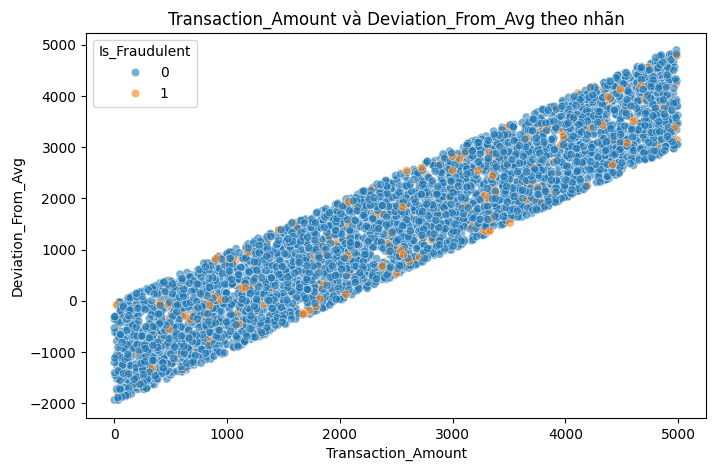

In [32]:
# 6.3 AMOUNT + DEVIATION COMBINATION

amount_deviation_summary = summarize_combination_fraud_rate(
    df_combo,
    ["High_Amount", "High_Deviation"]
)

print("Bảng 7.3. Fraud rate theo tổ hợp High_Amount và High_Deviation")
display(amount_deviation_summary)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_combo,
    x="Transaction_Amount",
    y="Deviation_From_Avg",
    hue="Is_Fraudulent",
    alpha=0.6
)

plt.title("Transaction_Amount và Deviation_From_Avg theo nhãn")
plt.xlabel("Transaction_Amount")
plt.ylabel("Deviation_From_Avg")
plt.show()

Bước này được thực hiện để kiểm tra xem sự kết hợp giữa số tiền giao dịch cao và độ lệch so với trung bình cao có liên quan đến tỷ lệ gian lận hay không. Trước đó, các biến số riêng lẻ chưa cho thấy khả năng phân tách mạnh, nên cần phân tích thêm các tổ hợp biến để xem khi nhiều điều kiện cùng xuất hiện thì fraud rate có thay đổi rõ hơn không.

Biểu đồ phân tán cho thấy `Transaction_Amount` và `Deviation_From_Avg` có quan hệ tăng cùng chiều khá rõ. Các điểm của lớp gian lận vẫn xuất hiện rải rác và chồng lấp nhiều với lớp bình thường, chưa tạo thành một cụm riêng biệt. Điều này cho thấy chỉ riêng cặp biến này chưa đủ để tách rõ fraud và normal bằng quan sát trực quan.

Bảng thống kê cho thấy nhóm `High_Amount = 0` và `High_Deviation = 1` có fraud rate cao nhất, đạt 5.98% với 15 fraud trên 251 giao dịch, Lift = 1.1905. Nhóm không cao ở cả hai biến có fraud rate 5.23%, gần với mức trung bình chung. Ngược lại, nhóm `High_Amount = 1` và `High_Deviation = 1` có fraud rate 4.40%, thấp hơn mức trung bình, còn nhóm chỉ có `High_Amount = 1` có fraud rate 3.59%.

Kết quả này cho thấy tổ hợp `Transaction_Amount` và `Deviation_From_Avg` có tạo ra một số khác biệt về fraud rate, nhưng tín hiệu chưa mạnh và không theo hướng đơn giản là “càng cao thì càng gian lận”. Vì vậy, ở bước Feature Engineering, bài làm vẫn có thể tạo biến tương tác như `Amount_x_Deviation`, nhưng cần để mô hình kiểm chứng mức độ hữu ích của đặc trưng này thay vì kết luận thủ công.


Bảng 7.4. Fraud rate theo tổ hợp High_Frequency và Short_TimeGap


,High_Frequency,Short_TimeGap,Total,Fraud_Count,Fraud_Rate,Fraud_Rate_%,Lift
2,1,0,983,57,0.0580,5.7986,1.1551
0,0,0,2734,135,0.0494,4.9378,0.9836
1,0,1,919,43,0.0468,4.6790,0.9321
3,1,1,364,16,0.0440,4.3956,0.8756


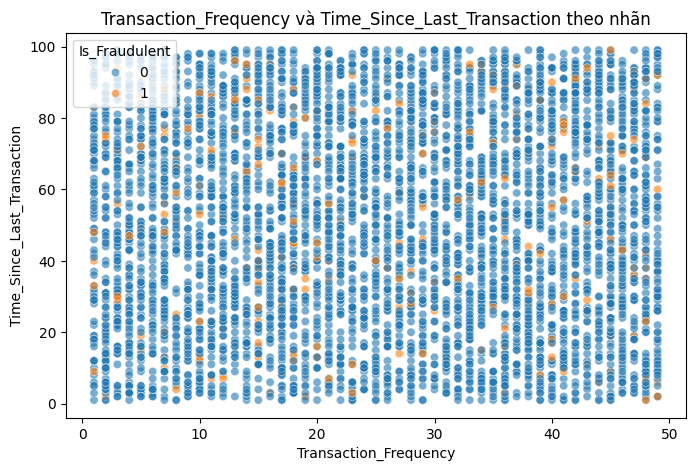

In [33]:
# 6.4 FREQUENCY + TIMEGAP COMBINATION

frequency_timegap_summary = summarize_combination_fraud_rate(
    df_combo,
    ["High_Frequency", "Short_TimeGap"]
)

print("Bảng 7.4. Fraud rate theo tổ hợp High_Frequency và Short_TimeGap")
display(frequency_timegap_summary)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_combo,
    x="Transaction_Frequency",
    y="Time_Since_Last_Transaction",
    hue="Is_Fraudulent",
    alpha=0.6
)

plt.title("Transaction_Frequency và Time_Since_Last_Transaction theo nhãn")
plt.xlabel("Transaction_Frequency")
plt.ylabel("Time_Since_Last_Transaction")
plt.show()

Biểu đồ phân tán cho thấy các điểm của lớp gian lận vẫn phân bố rải rác và chồng lấp nhiều với lớp bình thường. Không có vùng nào trên biểu đồ thể hiện sự tách biệt rõ ràng giữa hai lớp theo hai biến `Transaction_Frequency` và `Time_Since_Last_Transaction`.

Bảng thống kê cho thấy nhóm `High_Frequency = 1` và `Short_TimeGap = 0` có fraud rate cao nhất, đạt 5.80% với 57 fraud trên 983 giao dịch, Lift = 1.1551. Nhóm không có tần suất cao và không có khoảng thời gian ngắn có fraud rate 4.94%, gần với mức trung bình. Trong khi đó, nhóm có cả `High_Frequency = 1` và `Short_TimeGap = 1` chỉ có fraud rate 4.40%, thấp hơn mức trung bình.

Kết quả này cho thấy tổ hợp giữa tần suất giao dịch và khoảng thời gian giao dịch có tạo ra một số khác biệt về fraud rate, nhưng tín hiệu chưa mạnh và không theo hướng đơn giản là “tần suất cao, thời gian ngắn thì chắc chắn rủi ro hơn”. Vì vậy, ở bước Feature Engineering, bài làm vẫn có thể tạo biến như `Frequency_per_TimeGap`, nhưng cần để mô hình tự đánh giá mức độ hữu ích của đặc trưng này.


In [34]:
# 6.5 INTERACTION FEATURE DEMONSTRATION

df_interaction_demo = df_combo.copy()

df_interaction_demo["Amount_x_Deviation"] = (
    df_interaction_demo["Transaction_Amount"] *
    df_interaction_demo["Deviation_From_Avg"]
)

df_interaction_demo["Amount_to_Avg_Ratio"] = (
    df_interaction_demo["Transaction_Amount"] /
    (df_interaction_demo["Average_Transaction_Amount"] + 1e-6)
)

df_interaction_demo["Frequency_per_TimeGap"] = (
    df_interaction_demo["Transaction_Frequency"] /
    (df_interaction_demo["Time_Since_Last_Transaction"] + 1)
)

interaction_cols = [
    "Transaction_Amount",
    "Average_Transaction_Amount",
    "Deviation_From_Avg",
    "Transaction_Frequency",
    "Time_Since_Last_Transaction",
    "Amount_to_Avg_Ratio",
    "Amount_x_Deviation",
    "Frequency_per_TimeGap",
    "Is_Fraudulent"
]

print("Bảng 6.5. Minh họa một số interaction features")
display(df_interaction_demo[interaction_cols].head())

Bảng 6.5. Minh họa một số interaction features


,Transaction_Amount,Average_Transaction_Amount,Deviation_From_Avg,Transaction_Frequency,Time_Since_Last_Transaction,Amount_to_Avg_Ratio,Amount_x_Deviation,Frequency_per_TimeGap,Is_Fraudulent
0,1873.3300,627.7900,1245.5400,6,82,2.9840,2333307.4482,0.0723,0
1,4753.6200,518.6000,4235.0200,14,26,9.1663,20131675.7724,0.5185,1
2,3660.2400,1294.1900,2366.0500,12,42,2.8282,8660310.8520,0.2791,1
3,2993.6900,787.4000,2206.2900,27,16,3.8020,6604948.3101,1.5882,0
4,780.9400,1271.4100,-490.4700,26,22,0.6142,-383027.6418,1.1304,0


Kết quả cho thấy các interaction features đã được tạo đúng theo công thức. Ví dụ, ở dòng đầu tiên, `Amount_to_Avg_Ratio = 2.9840`, cho thấy số tiền giao dịch hiện tại cao hơn khoảng 2.98 lần so với giá trị giao dịch trung bình. `Amount_x_Deviation` của dòng này đạt khoảng 2,333,307.45, được tính từ `Transaction_Amount = 1873.33` và `Deviation_From_Avg = 1245.54`. Ngoài ra, `Frequency_per_TimeGap = 0.0723`, phản ánh tần suất giao dịch tương đối thấp so với khoảng thời gian từ giao dịch gần nhất.

Một số dòng gian lận có giá trị interaction khá cao. Chẳng hạn, dòng thứ hai có `Amount_to_Avg_Ratio = 9.1663`, `Amount_x_Deviation` khoảng 20,131,675.77 và được gán nhãn fraud. Tuy nhiên, cũng có các dòng không gian lận có giá trị tương tác đáng chú ý, ví dụ dòng thứ tư có `Frequency_per_TimeGap = 1.5882` nhưng nhãn vẫn là 0. Vì vậy, không thể kết luận chỉ riêng các interaction features này là đủ để phát hiện gian lận.

Từ kết quả này, các đặc trưng như `Amount_to_Avg_Ratio`, `Amount_x_Deviation` và `Frequency_per_TimeGap` sẽ được đưa vào bước Feature Engineering chính thức. Các biến này không thay thế biến gốc, mà bổ sung thêm cách biểu diễn để mô hình kiểm chứng mối quan hệ giữa số tiền, độ lệch, tần suất và khoảng thời gian từ giao dịch gần nhất.


### TỔNG KẾT NGẮN SAU EDA

Từ các phân tích EDA ở trên, có thể thấy bộ dữ liệu có ba vấn đề chính cần được xử lý ở các bước tiếp theo.

Thứ nhất, dữ liệu bị mất cân bằng lớp rõ rệt khi giao dịch gian lận chỉ chiếm khoảng 5.02%. Vì vậy, quá trình chia tập cần dùng stratified split và khi đánh giá mô hình không nên ưu tiên Accuracy, mà cần tập trung vào Recall, F2-score và PR-AUC.

Thứ hai, các biến số riêng lẻ chưa phân tách rõ hai lớp fraud và normal. Do đó, ở bước Feature Engineering cần tạo thêm các đặc trưng tương tác, đặc trưng tỷ lệ, đặc trưng thời gian và các biến đánh dấu vùng cực trị Q95/Q99 để giúp mô hình khai thác quan hệ phức tạp hơn.

Thứ ba, `Timestamp` đã bị loại bỏ khỏi mô hình hóa và không dùng để tạo đặc trưng.

Các bước xử lý chính thức sẽ được thực hiện sau khi chia train/validation/test nhằm hạn chế data leakage và đảm bảo đánh giá mô hình khách quan.


# 7. CHIA TẬP TRAIN / VALIDATION / TEST

Sau khi hoàn thành EDA, dữ liệu được chia thành ba tập: train, validation và test.

Việc chia tập được thực hiện trước các bước tiền xử lý chính như imputer, scaling, encoding, fit ngưỡng outlier và Feature Engineering. Mục đích là tránh data leakage, tức là tránh để thông tin từ validation/test ảnh hưởng vào quá trình học hoặc xử lý dữ liệu.

Do dữ liệu bị mất cân bằng lớp, bài làm sử dụng stratified split để giữ tỷ lệ giao dịch gian lận tương đối ổn định giữa các tập train, validation và test.

In [35]:
# 7.1 SEPARATE FEATURES AND TARGET

target_col = "Is_Fraudulent"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

print("\nTỷ lệ fraud toàn bộ dữ liệu:")
print(y.value_counts(normalize=True).mul(100).round(2))

Kích thước X: (5000, 8)
Kích thước y: (5000,)

Tỷ lệ fraud toàn bộ dữ liệu:
Is_Fraudulent
0   94.9800
1    5.0200
Name: proportion, dtype: float64


Ở bước này, biến mục tiêu `Is_Fraudulent` được tách khỏi các đặc trưng đầu vào.

`X` chứa các biến dùng để dự đoán, còn `y` chứa nhãn cần phân loại. Việc tách riêng feature và target giúp quy trình chia tập, tiền xử lý và huấn luyện mô hình được rõ ràng hơn.


In [36]:
# 7.2 TRAIN / VALIDATION / TEST SPLIT

TEST_SIZE = 0.15
VAL_SIZE = 0.15
RANDOM_STATE = 42

# Bước 1: tách test set trước
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

# Bước 2: tách validation set từ phần còn lại
# Vì validation cần chiếm 15% toàn bộ dữ liệu,
# nên tỷ lệ validation trong tập còn lại là 0.15 / 0.85
val_size_adjusted = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=val_size_adjusted,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (3500, 8) (3500,)
Validation shape: (750, 8) (750,)
Test shape: (750, 8) (750,)


Dữ liệu được chia theo tỷ lệ 70/15/15 cho train, validation và test.
Tỷ lệ này giúp tập train vẫn đủ lớn để mô hình học, đồng thời validation và test vẫn có đủ số lượng mẫu fraud để đánh giá trong bối cảnh dữ liệu mất cân bằng.

Do fraud chỉ chiếm khoảng 5.02%, nếu validation hoặc test quá nhỏ thì số lượng fraud trong các tập này sẽ rất ít, làm cho các metric như Recall, F2-score và PR-AUC dễ dao động. Vì vậy, validation và test được giữ ở mức 15% mỗi tập.

Tập validation được dùng để lựa chọn mô hình, tối ưu siêu tham số và điều chỉnh threshold. Tập test chỉ được sử dụng ở bước đánh giá cuối cùng để đảm bảo kết quả khách quan.

In [37]:
# 7.3 CHECK TARGET DISTRIBUTION AFTER SPLIT

def split_summary(y_data, split_name):
    total = len(y_data)
    fraud_count = int(y_data.sum())
    normal_count = total - fraud_count
    fraud_rate = fraud_count / total * 100

    return {
        "Split": split_name,
        "Total": total,
        "Normal_Count": normal_count,
        "Fraud_Count": fraud_count,
        "Fraud_Rate_%": round(fraud_rate, 2)
    }


split_summary_df = pd.DataFrame([
    split_summary(y_train, "Train"),
    split_summary(y_val, "Validation"),
    split_summary(y_test, "Test")
])

print("Bảng 8.1. Phân phối target sau khi chia tập")
display(split_summary_df)

Bảng 8.1. Phân phối target sau khi chia tập


,Split,Total,Normal_Count,Fraud_Count,Fraud_Rate_%
0,Train,3500,3325,175,5.0000
1,Validation,750,712,38,5.0700
2,Test,750,712,38,5.0700


Sau khi chia dữ liệu theo tỷ lệ 70/15/15, tập train có 3500 mẫu, validation có 750 mẫu và test có 750 mẫu.

Tỷ lệ fraud ở ba tập lần lượt là 5.00%, 5.07% và 5.07%, gần tương đương với tỷ lệ fraud ban đầu của toàn bộ dữ liệu là khoảng 5.02%.

Điều này cho thấy stratified split đã hoạt động đúng, giúp giữ phân phối nhãn ổn định giữa các tập. Đây là bước quan trọng trong bài toán mất cân bằng lớp, vì nếu tỷ lệ fraud giữa các tập bị lệch mạnh thì quá trình huấn luyện và đánh giá mô hình sẽ thiếu khách quan.


# 8. TIỀN XỬ LÝ CHÍNH SAU CHIA TẬP

Sau khi dữ liệu đã được chia thành train, validation và test, bài làm thực hiện tiền xử lý chính.

Các tham số như ngưỡng Q95/Q99, imputer, scaler và encoder chỉ được fit trên tập train, sau đó áp dụng cho validation và test. Cách làm này giúp tránh data leakage và đảm bảo quá trình đánh giá mô hình khách quan.

In [38]:
# 8.1 FIT FEATURE ENGINEERING PARAMETERS ON TRAIN ONLY

numeric_cols_base = [
    "Transaction_Amount",
    "Transaction_Frequency",
    "Average_Transaction_Amount",
    "Time_Since_Last_Transaction",
    "Deviation_From_Avg"
]

cat_cols_base = [
    "Location",
    "Transaction_Type"
]

fe_params = {}

for col in numeric_cols_base:
    fe_params[f"{col}_Q95"] = X_train[col].quantile(0.95)
    fe_params[f"{col}_Q99"] = X_train[col].quantile(0.99)

fe_params_df = pd.DataFrame({
    "Parameter": list(fe_params.keys()),
    "Value": list(fe_params.values())
})

print("Bảng 8.1. Các ngưỡng Q95/Q99 được fit trên tập train")
display(fe_params_df)

Bảng 8.1. Các ngưỡng Q95/Q99 được fit trên tập train


,Parameter,Value
0,Transaction_Amount_Q95,4753.6345
1,Transaction_Amount_Q99,4951.6787
2,Transaction_Frequency_Q95,47.0000
3,Transaction_Frequency_Q99,49.0000
4,Average_Transaction_Amount_Q95,1910.2520
5,Average_Transaction_Amount_Q99,1986.3758
6,Time_Since_Last_Transaction_Q95,95.0000
7,Time_Since_Last_Transaction_Q99,99.0000
8,Deviation_From_Avg_Q95,3928.6740
9,Deviation_From_Avg_Q99,4510.1506


Các ngưỡng Q95 và Q99 được tính trên tập train cho từng biến số. Đây là các ngưỡng dùng để tạo biến đánh dấu vùng giá trị cực trị ở bước Feature Engineering.

Việc fit các ngưỡng này trên train thay vì toàn bộ dữ liệu giúp tránh data leakage, vì validation và test không được tham gia vào quá trình xác định tham số tiền xử lý.


In [39]:
# 8.2. FEATURE ENGINEERING AFTER SPLIT

def fit_q_thresholds(X_data):
    numeric_for_threshold = [
        "Transaction_Amount",
        "Transaction_Frequency",
        "Average_Transaction_Amount",
        "Time_Since_Last_Transaction",
        "Deviation_From_Avg"
    ]

    q_thresholds = {}

    for col in numeric_for_threshold:
        q_thresholds[col] = {
            "Q95": X_data[col].quantile(0.95),
            "Q99": X_data[col].quantile(0.99)
        }

    return q_thresholds


def apply_feature_engineering(X_data, q_thresholds):
    X_fe = X_data.copy()

    # Loại bỏ các cột không dùng cho mô hình
    drop_cols = [
        "Transaction_ID",
        "Timestamp"
    ]

    X_fe = X_fe.drop(
        columns=[col for col in drop_cols if col in X_fe.columns],
        errors="ignore"
    )

    # Log features
    X_fe["Log_Transaction_Amount"] = np.log1p(
        X_fe["Transaction_Amount"]
    )

    X_fe["Log_Average_Transaction_Amount"] = np.log1p(
        X_fe["Average_Transaction_Amount"]
    )

    X_fe["Log_Transaction_Frequency"] = np.log1p(
        X_fe["Transaction_Frequency"]
    )

    # Ratio feature
    X_fe["Amount_to_Avg_Ratio"] = (
        X_fe["Transaction_Amount"] /
        (X_fe["Average_Transaction_Amount"] + 1e-6)
    )

    # Interaction features
    X_fe["Amount_x_Deviation"] = (
        X_fe["Transaction_Amount"] *
        X_fe["Deviation_From_Avg"]
    )

    X_fe["Frequency_per_TimeGap"] = (
        X_fe["Transaction_Frequency"] /
        (X_fe["Time_Since_Last_Transaction"] + 1)
    )

    # Extreme value flags based on train thresholds
    for col, thresholds in q_thresholds.items():
        X_fe[f"{col}_Above_Q95"] = (
            X_fe[col] >= thresholds["Q95"]
        ).astype(int)

        X_fe[f"{col}_Above_Q99"] = (
            X_fe[col] >= thresholds["Q99"]
        ).astype(int)

    return X_fe


q_thresholds = fit_q_thresholds(X_train)

X_train_fe = apply_feature_engineering(X_train, q_thresholds)
X_val_fe = apply_feature_engineering(X_val, q_thresholds)
X_test_fe = apply_feature_engineering(X_test, q_thresholds)

print("X_train_fe shape:", X_train_fe.shape)
print("X_val_fe shape:", X_val_fe.shape)
print("X_test_fe shape:", X_test_fe.shape)

print("\nMột số cột sau Feature Engineering:")
print(X_train_fe.columns.tolist())

X_train_fe shape: (3500, 23)
X_val_fe shape: (750, 23)
X_test_fe shape: (750, 23)

Một số cột sau Feature Engineering:
['Transaction_Amount', 'Location', 'Transaction_Type', 'Transaction_Frequency', 'Average_Transaction_Amount', 'Time_Since_Last_Transaction', 'Deviation_From_Avg', 'Log_Transaction_Amount', 'Log_Average_Transaction_Amount', 'Log_Transaction_Frequency', 'Amount_to_Avg_Ratio', 'Amount_x_Deviation', 'Frequency_per_TimeGap', 'Transaction_Amount_Above_Q95', 'Transaction_Amount_Above_Q99', 'Transaction_Frequency_Above_Q95', 'Transaction_Frequency_Above_Q99', 'Average_Transaction_Amount_Above_Q95', 'Average_Transaction_Amount_Above_Q99', 'Time_Since_Last_Transaction_Above_Q95', 'Time_Since_Last_Transaction_Above_Q99', 'Deviation_From_Avg_Above_Q95', 'Deviation_From_Avg_Above_Q99']


Feature Engineering được thực hiện trên ba tập train, validation và test sau khi chia tập. Kết quả cho thấy `X_train_fe` có kích thước `(3500, 23)`, `X_val_fe` có kích thước `(750, 23)` và `X_test_fe` có kích thước `(750, 23)`. Ba tập có cùng số lượng cột, cho thấy các bước tạo đặc trưng được áp dụng nhất quán.

Các đặc trưng sau Feature Engineering bao gồm nhóm biến gốc, biến log, biến tỷ lệ, biến tương tác và các biến đánh dấu vùng cực trị Q95/Q99. Cụ thể, bài làm tạo thêm các biến như `Log_Transaction_Amount`, `Amount_to_Avg_Ratio`, `Amount_x_Deviation`, `Frequency_per_TimeGap` và các biến dạng `Above_Q95`, `Above_Q99`.

Đáng chú ý, danh sách cột sau Feature Engineering không còn các biến liên quan đến `Timestamp` như `Hour`, `DayOfWeek`, `IsNight`, `IsWeekend` hoặc cyclic encoding. Điều này phù hợp với định hướng của bài: không xây dựng bài toán theo hướng time-series, mà tập trung vào phân loại nhị phân trên dữ liệu giao dịch dạng bảng.

Các ngưỡng Q95/Q99 được fit trên tập train và áp dụng lại cho validation/test, giúp tránh việc lấy thông tin từ tập đánh giá vào quá trình tạo đặc trưng. Đây là bước quan trọng để hạn chế data leakage trong tiền xử lý.


In [40]:
# KIỂM TRA REDUNDANCY SAU FEATURE ENGINEERING

# Deviation_From_Avg đã được xác nhận = Transaction_Amount - Average_Transaction_Amount
# → Đây là linear combination của 2 cột gốc, gây redundancy

redundant_note = """
⚠️  Ghi nhận redundancy:
- Deviation_From_Avg = Transaction_Amount - Average_Transaction_Amount (đã verify)
- Amount_to_Avg_Ratio = Transaction_Amount / Average_Transaction_Amount
- Amount_x_Deviation = Transaction_Amount * Deviation_From_Avg
                      = Transaction_Amount * (Transaction_Amount - Average_Transaction_Amount)

Với mô hình tuyến tính (Logistic Regression): multicollinearity có thể làm
hệ số không ổn định. Regularization L1/L2 trong Logistic sẽ xử lý một phần,
nhưng không loại bỏ hoàn toàn vấn đề.

Với mô hình cây (LightGBM, XGBoost, RF): ít nhạy cảm hơn với redundancy
vì chúng chọn feature tại mỗi split độc lập.

Quyết định: Giữ nguyên toàn bộ để mô hình tự học, nhưng ghi nhận đây
là đặc điểm của feature set hiện tại.
"""
print(redundant_note)

# Kiểm tra correlation giữa các biến liên quan
redundancy_cols = [
    "Transaction_Amount",
    "Average_Transaction_Amount",
    "Deviation_From_Avg",
]

corr_check = X_train_fe[redundancy_cols].corr()
print("Correlation matrix giữa các biến redundant:")
display(corr_check)


⚠️  Ghi nhận redundancy:
- Deviation_From_Avg = Transaction_Amount - Average_Transaction_Amount (đã verify)
- Amount_to_Avg_Ratio = Transaction_Amount / Average_Transaction_Amount
- Amount_x_Deviation = Transaction_Amount * Deviation_From_Avg
                      = Transaction_Amount * (Transaction_Amount - Average_Transaction_Amount)

Với mô hình tuyến tính (Logistic Regression): multicollinearity có thể làm
hệ số không ổn định. Regularization L1/L2 trong Logistic sẽ xử lý một phần,
nhưng không loại bỏ hoàn toàn vấn đề.

Với mô hình cây (LightGBM, XGBoost, RF): ít nhạy cảm hơn với redundancy
vì chúng chọn feature tại mỗi split độc lập.

Quyết định: Giữ nguyên toàn bộ để mô hình tự học, nhưng ghi nhận đây
là đặc điểm của feature set hiện tại.

Correlation matrix giữa các biến redundant:


,Transaction_Amount,Average_Transaction_Amount,Deviation_From_Avg
Transaction_Amount,1.0000,0.0010,0.9315
Average_Transaction_Amount,0.0010,1.0000,-0.3629
Deviation_From_Avg,0.9315,-0.3629,1.0000


In [41]:
# 8.3 BUILD PREPROCESSING PIPELINE

numeric_features = X_train_fe.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train_fe.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Số lượng numeric features:", len(numeric_features))
print("Số lượng categorical features:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

try:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("\nPreprocessing pipeline đã được khởi tạo.")

Số lượng numeric features: 21
Số lượng categorical features: 2

Categorical features:
['Location', 'Transaction_Type']

Preprocessing pipeline đã được khởi tạo.


Sau Feature Engineering, dữ liệu được chia thành hai nhóm: biến số và biến phân loại.

Các biến phân loại còn lại là `Location` và `Transaction_Type`, được xử lý bằng One-Hot Encoding vì chúng không có quan hệ thứ tự tự nhiên. Các biến số được xử lý bằng median imputer và RobustScaler để giảm ảnh hưởng của vùng giá trị cực trị.


In [42]:
# 8.4 FIT PREPROCESSOR ON TRAIN AND TRANSFORM ALL SPLITS

X_train_processed = preprocessor.fit_transform(X_train_fe)
X_val_processed = preprocessor.transform(X_val_fe)
X_test_processed = preprocessor.transform(X_test_fe)

print("X_train_processed shape:", X_train_processed.shape)
print("X_val_processed shape:", X_val_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

# Lấy tên feature sau preprocessing để phục vụ phân tích sau này
num_feature_names = numeric_features

if len(categorical_features) > 0:
    onehot = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = onehot.get_feature_names_out(categorical_features).tolist()
else:
    cat_feature_names = []

processed_feature_names = num_feature_names + cat_feature_names

print("\nTổng số feature sau preprocessing:", len(processed_feature_names))
print("\nMột số feature sau preprocessing:")
print(processed_feature_names[:30])

X_train_processed shape: (3500, 28)
X_val_processed shape: (750, 28)
X_test_processed shape: (750, 28)

Tổng số feature sau preprocessing: 28

Một số feature sau preprocessing:
['Transaction_Amount', 'Transaction_Frequency', 'Average_Transaction_Amount', 'Time_Since_Last_Transaction', 'Deviation_From_Avg', 'Log_Transaction_Amount', 'Log_Average_Transaction_Amount', 'Log_Transaction_Frequency', 'Amount_to_Avg_Ratio', 'Amount_x_Deviation', 'Frequency_per_TimeGap', 'Transaction_Amount_Above_Q95', 'Transaction_Amount_Above_Q99', 'Transaction_Frequency_Above_Q95', 'Transaction_Frequency_Above_Q99', 'Average_Transaction_Amount_Above_Q95', 'Average_Transaction_Amount_Above_Q99', 'Time_Since_Last_Transaction_Above_Q95', 'Time_Since_Last_Transaction_Above_Q99', 'Deviation_From_Avg_Above_Q95', 'Deviation_From_Avg_Above_Q99', 'Location_City_A', 'Location_City_B', 'Location_City_C', 'Location_City_D', 'Transaction_Type_Purchase', 'Transaction_Type_Transfer', 'Transaction_Type_Withdrawal']


Preprocessor được fit trên tập train và sau đó transform validation/test. Điều này đảm bảo các bước imputer, scaler và encoder chỉ học thông tin từ train, giúp tránh data leakage.

Preprocessor được fit trên tập train và sau đó transform validation và test. Kết quả cho thấy `X_train_processed` có kích thước `(3500, 28)`, `X_val_processed` có kích thước `(750, 28)` và `X_test_processed` có kích thước `(750, 28)`. Số cột tăng từ 23 lên 28 do One-Hot Encoding mở rộng hai biến phân loại `Location` (4 thành phố → 4 cột) và `Transaction_Type` (3 loại → 3 cột) thành 7 cột nhị phân, thay thế 2 cột gốc.

### Kết luận phần tiền xử lý

Sau khi tiền xử lý, ba tập train, validation và test đã được biến đổi nhất quán. Các tham số cần học như ngưỡng Q95/Q99, imputer, encoder và scaler đều được fit trên train, sau đó áp dụng cho validation/test để hạn chế data leakage. Các cột không phù hợp cho mô hình như `Transaction_ID` và `Timestamp` đã được loại bỏ. Dữ liệu sau preprocessing đã sẵn sàng cho bước xử lý mất cân bằng lớp và huấn luyện mô hình.

# 9. XỬ LÝ MẤT CÂN BẰNG LỚP

Ở các bước EDA, dữ liệu cho thấy lớp giao dịch gian lận chiếm tỷ lệ nhỏ hơn nhiều so với lớp giao dịch bình thường. Nếu huấn luyện trực tiếp trên dữ liệu mất cân bằng, mô hình có thể thiên về lớp bình thường và bỏ sót nhiều giao dịch gian lận.

Trong bài làm này, xử lý mất cân bằng lớp được tách thành một bước riêng sau tiền xử lý chính. Phương pháp được sử dụng là Random Oversampling trên tập train. Validation và test được giữ nguyên phân phối ban đầu để đảm bảo việc đánh giá phản ánh đúng dữ liệu thực tế.

Bài làm không sử dụng `class_weight='balanced'` hoặc `scale_pos_weight` ngầm trong mô hình, vì việc xử lý mất cân bằng đã được thực hiện rõ ràng tại bước này.

In [43]:
# 9.1 KIỂM TRA PHÂN PHỐI LỚP TRƯỚC KHI XỬ LÝ MẤT CÂN BẰNG

def class_distribution_table(y_data, dataset_name):
    """
    Tạo bảng phân phối lớp cho một tập dữ liệu.
    """
    counts = pd.Series(y_data).value_counts().sort_index()
    rates = pd.Series(y_data).value_counts(normalize=True).sort_index() * 100

    summary = pd.DataFrame({
        "Dataset": dataset_name,
        "Class": counts.index,
        "Count": counts.values,
        "Rate_%": rates.values
    })

    return summary


before_balance_summary = pd.concat(
    [
        class_distribution_table(y_train, "Train"),
        class_distribution_table(y_val, "Validation"),
        class_distribution_table(y_test, "Test")
    ],
    ignore_index=True
)

print("Bảng 9.1. Phân phối lớp trước khi xử lý mất cân bằng")
display(before_balance_summary)

normal_count = pd.Series(y_train).value_counts().get(0, 0)
fraud_count = pd.Series(y_train).value_counts().get(1, 0)

print("Số giao dịch bình thường trong train:", normal_count)
print("Số giao dịch gian lận trong train:", fraud_count)

if fraud_count > 0:
    print("Tỷ lệ mất cân bằng trong train: 1 fraud :", round(normal_count / fraud_count, 2), "normal")
else:
    print("Không có mẫu fraud trong train.")

Bảng 9.1. Phân phối lớp trước khi xử lý mất cân bằng


,Dataset,Class,Count,Rate_%
0,Train,0,3325,95.0000
1,Train,1,175,5.0000
2,Validation,0,712,94.9333
3,Validation,1,38,5.0667
4,Test,0,712,94.9333
5,Test,1,38,5.0667


Số giao dịch bình thường trong train: 3325
Số giao dịch gian lận trong train: 175
Tỷ lệ mất cân bằng trong train: 1 fraud : 19.0 normal


Bảng trên được sử dụng để kiểm tra lại phân phối lớp sau khi dữ liệu đã được chia thành train, validation và test. Đây là bước cần thiết trước khi xử lý mất cân bằng, vì phương pháp resampling chỉ được phép áp dụng trên tập train.

Kết quả cho thấy tập train vẫn bị mất cân bằng lớp, với số lượng giao dịch bình thường lớn hơn nhiều so với giao dịch gian lận. Nếu giữ nguyên phân phối này khi huấn luyện, mô hình có thể học thiên về lớp bình thường do đây là lớp chiếm đa số.

Validation và test được giữ nguyên phân phối ban đầu, vì hai tập này dùng để đánh giá mô hình. Nếu resampling validation hoặc test, kết quả đánh giá sẽ không còn phản ánh đúng tình huống dữ liệu thực tế.

In [44]:
# 9.2 RANDOM OVERSAMPLING TRÊN TẬP TRAIN

try:
    from imblearn.over_sampling import RandomOverSampler
except ImportError:
    !pip install -q imbalanced-learn
    from imblearn.over_sampling import RandomOverSampler


# sampling_strategy = 0.5 nghĩa là:
# số mẫu fraud sau oversampling = 50% số mẫu normal
ros = RandomOverSampler(
    sampling_strategy=0.5,
    random_state=RANDOM_STATE
)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train_processed,
    y_train
)

print("Đã áp dụng RandomOverSampler trên tập train.")
print("X_train_processed shape trước xử lý:", X_train_processed.shape)
print("X_train_balanced shape sau xử lý:", X_train_balanced.shape)

print("\nValidation và test giữ nguyên:")
print("X_val_processed shape:", X_val_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

Đã áp dụng RandomOverSampler trên tập train.
X_train_processed shape trước xử lý: (3500, 28)
X_train_balanced shape sau xử lý: (4987, 28)

Validation và test giữ nguyên:
X_val_processed shape: (750, 28)
X_test_processed shape: (750, 28)


RandomOverSampler được áp dụng trên tập train sau khi dữ liệu đã được tiền xử lý. Trước khi xử lý mất cân bằng, `X_train_processed` có kích thước `(3500, 28)`. Sau khi áp dụng RandomOverSampler với `sampling_strategy = 0.5`, kích thước tập train tăng lên thành `(4987, 28)`.

Việc số lượng dòng tăng từ 3500 lên 4987 cho thấy phương pháp oversampling đã bổ sung thêm các mẫu thuộc lớp thiểu số bằng cách lấy mẫu lặp lại từ các giao dịch fraud có sẵn trong tập train. Số lượng cột vẫn giữ nguyên là 28, nghĩa là bước này chỉ thay đổi số lượng mẫu huấn luyện, không tạo thêm đặc trưng mới.

Validation và test vẫn giữ nguyên kích thước lần lượt là `(750, 28)` và `(750, 28)`. Điều này đúng với quy trình học máy vì resampling chỉ được áp dụng trên train set. Nếu resampling validation hoặc test, kết quả đánh giá sẽ không còn phản ánh đúng phân phối dữ liệu thực tế.


In [45]:
# 9.3 KIỂM TRA PHÂN PHỐI LỚP SAU RANDOM OVERSAMPLING

after_balance_train_summary = class_distribution_table(
    y_train_balanced,
    "Train sau RandomOverSampler"
)

print("Bảng 9.3. Phân phối lớp train sau xử lý mất cân bằng")
display(after_balance_train_summary)

normal_count_after = pd.Series(y_train_balanced).value_counts().get(0, 0)
fraud_count_after = pd.Series(y_train_balanced).value_counts().get(1, 0)

print("Số giao dịch bình thường sau xử lý:", normal_count_after)
print("Số giao dịch gian lận sau xử lý:", fraud_count_after)

if fraud_count_after > 0:
    print(
        "Tỷ lệ sau xử lý: 1 fraud :",
        round(normal_count_after / fraud_count_after, 2),
        "normal"
    )

Bảng 9.3. Phân phối lớp train sau xử lý mất cân bằng


,Dataset,Class,Count,Rate_%
0,Train sau RandomOverSampler,0,3325,66.6734
1,Train sau RandomOverSampler,1,1662,33.3266


Số giao dịch bình thường sau xử lý: 3325
Số giao dịch gian lận sau xử lý: 1662
Tỷ lệ sau xử lý: 1 fraud : 2.0 normal


Sau khi áp dụng RandomOverSampler, tập train có 3325 mẫu bình thường và 1662 mẫu gian lận. Tỷ lệ lớp sau xử lý là khoảng 1 fraud : 2 normal, tương ứng lớp bình thường chiếm 66.67% và lớp gian lận chiếm 33.33%.

Như vậy, dữ liệu train sau xử lý chưa cân bằng tuyệt đối theo tỷ lệ 1:1. Tuy nhiên, mục tiêu của bước này không phải ép hai lớp bằng nhau hoàn toàn, mà là giảm mức độ mất cân bằng một cách có kiểm soát. So với trạng thái ban đầu khoảng 1 fraud : 19 normal, tỷ lệ sau xử lý đã bớt lệch hơn đáng kể.

Việc không ép dữ liệu về 1:1 giúp hạn chế làm phân phối train khác quá xa so với dữ liệu ban đầu. Từ bước huấn luyện mô hình trở đi, các mô hình sẽ học trên `X_train_balanced` và `y_train_balanced`, còn validation/test vẫn giữ nguyên để đánh giá khách quan. Vì RandomOverSampler lặp lại các mẫu fraud đã có, bài làm cần tiếp tục kiểm tra overfitting ở các bước sau bằng cách so sánh kết quả train và validation.


In [46]:
# 9.4 CHECKPOINT SAU XỬ LÝ MẤT CÂN BẰNG


print("Dữ liệu dùng để train model từ mục 10 trở đi:")
print("X_train_balanced:", X_train_balanced.shape)
print("y_train_balanced:", pd.Series(y_train_balanced).shape)

print("\nDữ liệu dùng để validation:")
print("X_val_processed:", X_val_processed.shape)
print("y_val:", y_val.shape)

print("\nDữ liệu dùng để test:")
print("X_test_processed:", X_test_processed.shape)
print("y_test:", y_test.shape)

print("\nLưu ý:")
print("- Train model bằng X_train_balanced, y_train_balanced")
print("- Đánh giá validation bằng X_val_processed, y_val")
print("- Đánh giá test bằng X_test_processed, y_test")
print("- Không dùng class_weight='balanced' hoặc scale_pos_weight ngầm trong model")

Dữ liệu dùng để train model từ mục 10 trở đi:
X_train_balanced: (4987, 28)
y_train_balanced: (4987,)

Dữ liệu dùng để validation:
X_val_processed: (750, 28)
y_val: (750,)

Dữ liệu dùng để test:
X_test_processed: (750, 28)
y_test: (750,)

Lưu ý:
- Train model bằng X_train_balanced, y_train_balanced
- Đánh giá validation bằng X_val_processed, y_val
- Đánh giá test bằng X_test_processed, y_test
- Không dùng class_weight='balanced' hoặc scale_pos_weight ngầm trong model


Lưu ý: `X_train_balanced` và `y_train_balanced` được sử dụng cho bước huấn luyện mô hình ban đầu ở mục 10. Từ mục 11 trở đi, sampling strategy được tối ưu trực tiếp trong Optuna trên tập `X_trainval` (train + validation gộp lại), nên `X_train_balanced` không còn được dùng nữa.

# 10. HUẤN LUYỆN MÔ HÌNH

Sau khi dữ liệu đã được tiền xử lý, bài làm tiến hành huấn luyện một số mô hình ban đầu để tạo mốc so sánh.

Phần này gồm mô hình baseline đơn giản và các mô hình cây. Các mô hình được đánh giá trên tập validation để so sánh trước khi chuyển sang bước tối ưu siêu tham số.

In [47]:
# 10.1 HÀM ĐÁNH GIÁ MÔ HÌNH

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

def evaluate_model(
    model,
    X_eval,
    y_eval,
    model_name,
    threshold=0.5
):
    """
    Đánh giá mô hình phân loại nhị phân tại một threshold cụ thể.

    Lưu ý:
    - ROC-AUC và PR-AUC được tính từ xác suất dự đoán.
    - Accuracy, Precision, Recall, F1, F2, TN, FP, FN, TP được tính từ nhãn dự đoán.
    """

    # Lấy xác suất dự đoán lớp 1 nếu mô hình hỗ trợ predict_proba
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_eval)[:, 1]
    else:
        # Trường hợp mô hình không có predict_proba
        y_proba = model.decision_function(X_eval)

    # Chuyển xác suất thành nhãn dự đoán theo threshold
    y_pred = (y_proba >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_eval,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # Tính các chỉ số đánh giá
    result = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1": f1_score(y_eval, y_pred, zero_division=0),
        "F2": fbeta_score(y_eval, y_pred, beta=2, zero_division=0),
        "ROC_AUC": roc_auc_score(y_eval, y_proba),
        "PR_AUC": average_precision_score(y_eval, y_proba),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    return result

In [48]:
# 10.2 KHỞI TẠO CÁC MÔ HÌNH BAN ĐẦU

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# Không dùng class_weight='balanced' vì mất cân bằng đã xử lý ở mục 9
models = {
    "Dummy": DummyClassifier(
        strategy="most_frequent"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
}

print("Các mô hình ban đầu:")
for name in models.keys():
    print("-", name)

Các mô hình ban đầu:
- Dummy
- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees
- LightGBM


In [49]:
# 10.3 HUẤN LUYỆN MÔ HÌNH BAN ĐẦU VÀ ĐÁNH GIÁ TRÊN VALIDATION

trained_models = {}
initial_results = []

print("Thông tin huấn luyện mô hình ban đầu")
print("- Tập train dùng để huấn luyện:", X_train_balanced.shape)
print("- Tập validation dùng để đánh giá:", X_val_processed.shape)
print("- Cách xử lý mất cân bằng:", "RandomOverSampler trên tập train")
print("- Threshold đánh giá ban đầu:", 0.5)
print("=" * 70)

for model_name, model in models.items():

    print(f"Đang huấn luyện mô hình: {model_name}")

    # 1. Train mô hình trên tập train đã xử lý mất cân bằng
    model.fit(X_train_balanced, y_train_balanced)

    # 2. Lưu mô hình đã train
    trained_models[model_name] = model

    # 3. Đánh giá mô hình trên validation set gốc
    result = evaluate_model(
        model=model,
        X_eval=X_val_processed,
        y_eval=y_val,
        model_name=model_name,
        threshold=0.5
    )

    # 4. Bổ sung thông tin để bảng kết quả dễ hiểu
    result["Training_Data"] = "X_train_balanced, y_train_balanced"
    result["Evaluation_Data"] = "X_val_processed, y_val"
    result["Imbalance_Handling"] = "RandomOverSampler"
    result["Training_Status"] = "Trained"

    initial_results.append(result)

initial_results_df = pd.DataFrame(initial_results)

# Sắp xếp theo PR-AUC trước, sau đó F2
initial_results_df = initial_results_df.sort_values(
    by=["PR_AUC", "F2"],
    ascending=False
).reset_index(drop=True)

# Sắp xếp lại thứ tự cột để người đọc nhìn vào là hiểu ngay
initial_display_cols = [
    "Model",
    "Training_Status",
    "Training_Data",
    "Evaluation_Data",
    "Imbalance_Handling",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "F2",
    "ROC_AUC",
    "PR_AUC",
    "TN",
    "FP",
    "FN",
    "TP"
]

print("\nBảng 10.3. Các mô hình ban đầu đã huấn luyện và kết quả đánh giá trên validation set")
display(initial_results_df[initial_display_cols])

Thông tin huấn luyện mô hình ban đầu
- Tập train dùng để huấn luyện: (4987, 28)
- Tập validation dùng để đánh giá: (750, 28)
- Cách xử lý mất cân bằng: RandomOverSampler trên tập train
- Threshold đánh giá ban đầu: 0.5
Đang huấn luyện mô hình: Dummy
Đang huấn luyện mô hình: Logistic Regression
Đang huấn luyện mô hình: Decision Tree
Đang huấn luyện mô hình: Random Forest
Đang huấn luyện mô hình: Extra Trees
Đang huấn luyện mô hình: LightGBM

Bảng 10.3. Các mô hình ban đầu đã huấn luyện và kết quả đánh giá trên validation set


,Model,Training_Status,Training_Data,Evaluation_Data,Imbalance_Handling,Threshold,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Logistic Regression,Trained,"X_train_balanced, y_train_balanced","X_val_processed, y_val",RandomOverSampler,0.5000,0.9467,0.2500,0.0263,0.0476,0.0321,0.4839,0.0608,709,3,37,1
1,Extra Trees,Trained,"X_train_balanced, y_train_balanced","X_val_processed, y_val",RandomOverSampler,0.5000,0.9480,0.0000,0.0000,0.0000,0.0000,0.4693,0.0531,711,1,38,0
2,Decision Tree,Trained,"X_train_balanced, y_train_balanced","X_val_processed, y_val",RandomOverSampler,0.5000,0.9413,0.0000,0.0000,0.0000,0.0000,0.4964,0.0507,706,6,38,0
3,Dummy,Trained,"X_train_balanced, y_train_balanced","X_val_processed, y_val",RandomOverSampler,0.5000,0.9493,0.0000,0.0000,0.0000,0.0000,0.5000,0.0507,712,0,38,0
4,Random Forest,Trained,"X_train_balanced, y_train_balanced","X_val_processed, y_val",RandomOverSampler,0.5000,0.9480,0.0000,0.0000,0.0000,0.0000,0.4186,0.0458,711,1,38,0
5,LightGBM,Trained,"X_train_balanced, y_train_balanced","X_val_processed, y_val",RandomOverSampler,0.5000,0.9280,0.0000,0.0000,0.0000,0.0000,0.4315,0.0432,696,16,38,0


In [50]:
# 10.4 CHỌN MÔ HÌNH TỐT NHẤT TẠM THỜI THEO PR-AUC

best_initial_model_name = initial_results_df.iloc[0]["Model"]
best_initial_model = trained_models[best_initial_model_name]

print("Mô hình tốt nhất tạm thời theo PR-AUC:")
print(best_initial_model_name)

print("\nBảng 10.4. Xếp hạng mô hình ban đầu")
display(
    initial_results_df[
        [
            "Model",
            "Threshold",
            "Precision",
            "Recall",
            "F1",
            "F2",
            "ROC_AUC",
            "PR_AUC",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ]
)

Mô hình tốt nhất tạm thời theo PR-AUC:
Logistic Regression

Bảng 10.4. Xếp hạng mô hình ban đầu


,Model,Threshold,Precision,Recall,F1,F2,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,Logistic Regression,0.5000,0.2500,0.0263,0.0476,0.0321,0.4839,0.0608,709,3,37,1
1,Extra Trees,0.5000,0.0000,0.0000,0.0000,0.0000,0.4693,0.0531,711,1,38,0
2,Decision Tree,0.5000,0.0000,0.0000,0.0000,0.0000,0.4964,0.0507,706,6,38,0
3,Dummy,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0507,712,0,38,0
4,Random Forest,0.5000,0.0000,0.0000,0.0000,0.0000,0.4186,0.0458,711,1,38,0
5,LightGBM,0.5000,0.0000,0.0000,0.0000,0.0000,0.4315,0.0432,696,16,38,0


Bảng 10.4 xếp hạng các mô hình ban đầu theo PR-AUC trên validation set. PR-AUC được ưu tiên ở bước này vì bài toán có mất cân bằng lớp, trong đó fraud chỉ chiếm tỷ lệ nhỏ. Chỉ số này phù hợp hơn Accuracy khi cần đánh giá khả năng xếp hạng các giao dịch gian lận so với giao dịch bình thường.

Kết quả cho thấy `Logistic Regression` là mô hình tốt nhất tạm thời theo PR-AUC, đạt 0.0608. Tuy nhiên, kết quả này vẫn còn thấp. Tại threshold mặc định 0.5, mô hình chỉ phát hiện được 1 trên 38 giao dịch gian lận, tương ứng Recall = 0.0263 và TP = 1. Mô hình dự đoán 4 giao dịch là fraud, trong đó có 1 dự đoán đúng và 3 dự đoán sai, nên Precision đạt 0.2500.

Các mô hình còn lại chưa phát hiện được giao dịch gian lận nào tại threshold 0.5. `Extra Trees`, `Decision Tree`, `Dummy`, `Random Forest` và `LightGBM` đều có TP = 0 và FN = 38, nghĩa là toàn bộ 38 giao dịch fraud trong validation set bị dự đoán thành normal. Riêng `LightGBM` có FP = 16, tức là mô hình tạo ra nhiều cảnh báo sai hơn nhưng vẫn không phát hiện được fraud thật nào.

Một số mô hình có Accuracy cao, ví dụ `Dummy` đạt 0.9493, `Extra Trees` và `Random Forest` đạt 0.9480. Tuy nhiên, Accuracy cao trong trường hợp này chủ yếu đến từ việc lớp normal chiếm đa số. Vì vậy, Accuracy không đủ để đánh giá chất lượng mô hình trong bài toán phát hiện gian lận.

Như vậy, `Logistic Regression` được chọn là mô hình tốt nhất tạm thời trong nhóm mô hình ban đầu theo PR-AUC. Tuy nhiên, kết quả này chưa đủ để kết luận mô hình hoạt động tốt. Các bước tiếp theo cần tiếp tục tối ưu siêu tham số, kiểm tra overfitting/underfitting và tuning threshold trên validation set để cải thiện khả năng phát hiện fraud.


In [51]:
# 10.5 NO-SKILL PR-AUC BASELINE TRÊN VALIDATION

val_fraud_rate = y_val.mean()
best_initial_pr_auc = initial_results_df.iloc[0]["PR_AUC"]

print("Tỷ lệ fraud trong validation set:", round(val_fraud_rate, 4))
print("No-skill PR-AUC baseline:", round(val_fraud_rate, 4))
print("PR-AUC tốt nhất trong các mô hình ban đầu:", round(best_initial_pr_auc, 4))
print("Chênh lệch so với no-skill baseline:", round(best_initial_pr_auc - val_fraud_rate, 4))

Tỷ lệ fraud trong validation set: 0.0507
No-skill PR-AUC baseline: 0.0507
PR-AUC tốt nhất trong các mô hình ban đầu: 0.0608
Chênh lệch so với no-skill baseline: 0.0101


Trong bài toán mất cân bằng lớp, no-skill PR-AUC thường xấp xỉ tỷ lệ lớp dương, tức là tỷ lệ giao dịch gian lận trong validation set.

Kết quả cho thấy tỷ lệ fraud trong validation set là 0.0507, tương ứng no-skill PR-AUC baseline = 0.0507. PR-AUC tốt nhất trong nhóm mô hình ban đầu là 0.0608, thuộc về `Logistic Regression`. Như vậy, mô hình tốt nhất hiện tại chỉ cao hơn baseline khoảng 0.0101.

Điều này cho thấy các mô hình ban đầu mới chỉ cải thiện rất nhẹ so với mức dự đoán không có kỹ năng phân biệt rõ ràng. Nói cách khác, khả năng xếp hạng fraud cao hơn normal vẫn còn yếu. Vì vậy, không nên kết luận mô hình hiện tại đã phát hiện gian lận tốt, mà cần tiếp tục tối ưu mô hình, kiểm tra overfitting/underfitting và điều chỉnh threshold trên validation set.


Lưu ý: mục 10 vẫn sử dụng validation set riêng để đánh giá sơ bộ. Từ mục 11 trở đi, validation được gộp vào trainval để tăng số mẫu fraud cho CV

# 11. TỐI ƯU SIÊU THAM SỐ

Ở bước này, bài làm chỉ giữ lại 4 mô hình có tiềm năng nhất để tuning: Logistic Regression, Random Forest, XGBoost và LightGBM. Decision Tree và Extra Trees được loại khỏi bước tuning vì Decision Tree đơn lẻ thường bị overfitting mạnh và kém ổn định hơn các ensemble method, trong khi Extra Trees có cơ chế tương tự Random Forest nhưng ít được dùng làm mô hình chính trong bài toán fraud detection thực tế. Việc tập trung vào 4 mô hình trên giúp giảm thời gian tính toán và giữ bài phân tích có trọng tâm.

In [52]:
# 11.1 CẤU HÌNH TỐI ƯU SIÊU THAM SỐ

try:
    import optuna
except ImportError:
    !pip install -q optuna
    import optuna

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score
from imblearn.over_sampling import RandomOverSampler

N_TRIALS    = 30
N_CV_FOLDS  = 3
RANDOM_STATE = 42

# Gộp train + val để CV có thêm mẫu fraud
# (test set vẫn hoàn toàn tách biệt, không được chạm vào)
X_trainval = np.vstack([X_train_processed, X_val_processed])
y_trainval = np.concatenate([y_train.values, y_val.values])

print("X_trainval shape :", X_trainval.shape)
print("Fraud trong trainval:", int(y_trainval.sum()), "/", len(y_trainval))
print("Fraud rate          :", round(y_trainval.mean() * 100, 2), "%")
print()
print("N_TRIALS   :", N_TRIALS)
print("N_CV_FOLDS :", N_CV_FOLDS)
print("Tổng số fits dự kiến:", N_TRIALS * N_CV_FOLDS * 4, "(4 mô hình)")

X_trainval shape : (4250, 28)
Fraud trong trainval: 213 / 4250
Fraud rate          : 5.01 %

N_TRIALS   : 30
N_CV_FOLDS : 3
Tổng số fits dự kiến: 360 (4 mô hình)


Phần tối ưu siêu tham số được thực hiện với `N_TRIALS = 30` cho mỗi mô hình. Dữ liệu dùng để tuning là tập `X_trainval` — kết hợp train và validation, có kích thước `(4250, 28)`. Việc đánh giá trong mỗi trial được thực hiện qua `Stratified K-Fold CV` với 3 folds trực tiếp trên `X_trainval`, không dùng test set. Metric tối ưu là PR-AUC trung bình qua các fold."

Ở bước này, các mô hình không sử dụng `class_weight='balanced'` hoặc `scale_pos_weight`, vì mất cân bằng lớp đã được xử lý riêng ở mục 9.


In [53]:
# 11.2 OPTUNA TUNING - LOGISTIC REGRESSION

def objective_logistic(trial):
    sampling_strategy = trial.suggest_categorical(
        "sampling_strategy", [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
    )
    C       = trial.suggest_float("C", 1e-3, 10.0, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])

    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver="liblinear",
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []

    for train_idx, val_idx in skf.split(X_trainval, y_trainval):
        X_fold_tr, y_fold_tr = X_trainval[train_idx], y_trainval[train_idx]
        X_fold_val, y_fold_val = X_trainval[val_idx],  y_trainval[val_idx]

        ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=RANDOM_STATE)
        X_res, y_res = ros.fit_resample(X_fold_tr, y_fold_tr)

        model.fit(X_res, y_res)
        y_proba = model.predict_proba(X_fold_val)[:, 1]
        fold_scores.append(average_precision_score(y_fold_val, y_proba))

    return np.mean(fold_scores)


optuna.logging.set_verbosity(optuna.logging.WARNING)

study_logistic = optuna.create_study(
    direction="maximize",
    study_name="Logistic_CV",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_logistic.optimize(objective_logistic, n_trials=N_TRIALS, show_progress_bar=True)

best_logistic_all       = study_logistic.best_params.copy()
best_logistic_sampling  = best_logistic_all.pop("sampling_strategy")
best_logistic_params    = best_logistic_all
best_logistic_score     = study_logistic.best_value

print("Best sampling_strategy :", best_logistic_sampling)
print("Best params            :", best_logistic_params)
print("Best CV PR-AUC         :", round(best_logistic_score, 4))

  0%|          | 0/30 [00:00<?, ?it/s]

Best sampling_strategy : 0.1
Best params            : {'C': 0.4050104259141603, 'penalty': 'l2'}
Best CV PR-AUC         : 0.0607


Optuna đã thực hiện 30 trials để tìm bộ siêu tham số tốt nhất cho Logistic Regression. Kết quả tốt nhất đạt PR-AUC = 0.0607 với `C = 0.4050` và `penalty = l2`.

So với Logistic Regression ban đầu có PR-AUC = 0.0608, kết quả sau tuning chỉ tăng nhẹ. Điều này cho thấy việc điều chỉnh siêu tham số giúp cải thiện mô hình, nhưng mức cải thiện chưa lớn. Ngoài ra, phần lớn các trial tốt đều sử dụng `penalty = l2`, cho thấy regularization dạng l2 phù hợp hơn trong thí nghiệm này so với một số cấu hình khác.

Tuy nhiên, PR-AUC = 0.0629 vẫn chỉ cao hơn không nhiều so với no-skill baseline của validation set là 0.0507. Vì vậy, chưa thể kết luận Logistic Regression đã phân biệt tốt fraud và normal, mà chỉ có thể xem đây là mô hình có kết quả tốt nhất tạm thời trong nhóm đã thử.


In [54]:
# 11.3 OPTUNA TUNING - RANDOM FOREST

def objective_random_forest(trial):
    sampling_strategy  = trial.suggest_categorical(
        "sampling_strategy", [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
    )
    n_estimators       = trial.suggest_int("n_estimators", 100, 400)
    max_depth          = trial.suggest_int("max_depth", 3, 15)
    min_samples_split  = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf   = trial.suggest_int("min_samples_leaf", 1, 20)
    max_features       = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []

    for train_idx, val_idx in skf.split(X_trainval, y_trainval):
        X_fold_tr, y_fold_tr = X_trainval[train_idx], y_trainval[train_idx]
        X_fold_val, y_fold_val = X_trainval[val_idx],  y_trainval[val_idx]

        ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=RANDOM_STATE)
        X_res, y_res = ros.fit_resample(X_fold_tr, y_fold_tr)

        model.fit(X_res, y_res)
        y_proba = model.predict_proba(X_fold_val)[:, 1]
        fold_scores.append(average_precision_score(y_fold_val, y_proba))

    return np.mean(fold_scores)


study_rf = optuna.create_study(
    direction="maximize",
    study_name="RandomForest_CV",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_rf.optimize(objective_random_forest, n_trials=N_TRIALS, show_progress_bar=True)

best_rf_all      = study_rf.best_params.copy()
best_rf_sampling = best_rf_all.pop("sampling_strategy")
best_rf_params   = best_rf_all
best_rf_score    = study_rf.best_value

print("Best sampling_strategy :", best_rf_sampling)
print("Best params            :", best_rf_params)
print("Best CV PR-AUC         :", round(best_rf_score, 4))

  0%|          | 0/30 [00:00<?, ?it/s]

Best sampling_strategy : 0.1
Best params            : {'n_estimators': 113, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': 'sqrt'}
Best CV PR-AUC         : 0.058


Optuna đã thực hiện 30 trials để tìm bộ siêu tham số tốt nhất cho Random Forest. Kết quả tốt nhất đạt CV PR-AUC = 0.0580 với `n_estimators = 113`, `max_depth = 7`, `min_samples_split = 9`, `min_samples_leaf = 6` và `max_features = sqrt`. `sampling_strategy = 0.1` được chọn, nghĩa là sau oversampling, tỷ lệ fraud chỉ tăng nhẹ lên khoảng 10% số mẫu normal.
So với các mô hình khác, Random Forest đạt CV PR-AUC thấp nhất trong nhóm 4 mô hình được tuning. Điều này có thể do Random Forest nhạy cảm hơn với nhiễu dữ liệu khi tín hiệu phân biệt giữa hai lớp yếu, và cần nhiều trees với độ sâu cao hơn để nắm bắt tín hiệu nhỏ — nhưng điều đó lại làm tăng nguy cơ overfit trên dữ liệu train.

In [55]:
# 11.4 OPTUNA TUNING - XGBOOST

from xgboost import XGBClassifier

def objective_xgboost(trial):
    sampling_strategy = trial.suggest_categorical(
        "sampling_strategy", [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
    )

    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 100, 400),
        "max_depth"       : trial.suggest_int("max_depth", 2, 6),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state"    : RANDOM_STATE,
        "eval_metric"     : "logloss",
        "n_jobs"          : -1
    }

    skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []

    for train_idx, val_idx in skf.split(X_trainval, y_trainval):
        X_fold_tr, y_fold_tr = X_trainval[train_idx], y_trainval[train_idx]
        X_fold_val, y_fold_val = X_trainval[val_idx],  y_trainval[val_idx]

        ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=RANDOM_STATE)
        X_res, y_res = ros.fit_resample(X_fold_tr, y_fold_tr)

        model = XGBClassifier(**params)
        model.fit(X_res, y_res)
        y_proba = model.predict_proba(X_fold_val)[:, 1]
        fold_scores.append(average_precision_score(y_fold_val, y_proba))

    return np.mean(fold_scores)


study_xgb = optuna.create_study(
    direction="maximize",
    study_name="XGBoost_CV",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_xgb.optimize(objective_xgboost, n_trials=N_TRIALS, show_progress_bar=True)

best_xgb_all      = study_xgb.best_params.copy()
best_xgb_sampling = best_xgb_all.pop("sampling_strategy")
best_xgb_params   = best_xgb_all
best_xgb_score    = study_xgb.best_value

print("Best sampling_strategy :", best_xgb_sampling)
print("Best params            :", best_xgb_params)
print("Best CV PR-AUC         :", round(best_xgb_score, 4))

  0%|          | 0/30 [00:00<?, ?it/s]

Best sampling_strategy : 0.8
Best params            : {'n_estimators': 270, 'max_depth': 4, 'learning_rate': 0.14497661132495113, 'subsample': 0.9816212048264373, 'colsample_bytree': 0.9992140742504716, 'reg_alpha': 0.2813944448341879, 'reg_lambda': 0.0029027317640727673}
Best CV PR-AUC         : 0.0626


Optuna đã thực hiện 30 trials để tìm bộ siêu tham số tốt nhất cho XGBoost. Kết quả tốt nhất đạt CV `PR-AUC = 0.0626` với `n_estimators = 270`, `max_depth = 4`, `learning_rate ≈ 0.145` và `sampling_strategy = 0.8`. Mức `sampling_strategy` cao hơn so với Logistic và Random Forest cho thấy XGBoost có xu hướng cần dữ liệu fraud chiếm tỷ lệ cao hơn trong quá trình học để tạo tín hiệu phân biệt.
XGBoost đạt CV PR-AUC cao nhất trong nhóm 4 mô hình, cho thấy gradient boosting có khả năng khai thác tín hiệu yếu tốt hơn trên bộ dữ liệu này so với Logistic Regression và Random Forest.

In [56]:
# 11.5 OPTUNA TUNING - LIGHTGBM

from lightgbm import LGBMClassifier

def objective_lightgbm(trial):
    sampling_strategy = trial.suggest_categorical(
        "sampling_strategy", [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
    )

    params = {
        "n_estimators"        : trial.suggest_int("n_estimators", 100, 400),
        "num_leaves"          : trial.suggest_int("num_leaves", 15, 63),
        "max_depth"           : trial.suggest_int("max_depth", 2, 8),
        "learning_rate"       : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_samples"   : trial.suggest_int("min_child_samples", 10, 60),
        "subsample"           : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree"    : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha"           : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"          : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state"        : RANDOM_STATE,
        "bagging_seed"        : RANDOM_STATE,
        "feature_fraction_seed": RANDOM_STATE,
        "data_random_seed"    : RANDOM_STATE,
        "deterministic"       : True,
        "force_col_wise"      : True,
        "n_jobs"              : -1,
        "verbose"             : -1
    }

    skf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []

    for train_idx, val_idx in skf.split(X_trainval, y_trainval):
        X_fold_tr, y_fold_tr = X_trainval[train_idx], y_trainval[train_idx]
        X_fold_val, y_fold_val = X_trainval[val_idx],  y_trainval[val_idx]

        ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=RANDOM_STATE)
        X_res, y_res = ros.fit_resample(X_fold_tr, y_fold_tr)

        model = LGBMClassifier(**params)
        model.fit(X_res, y_res)
        y_proba = model.predict_proba(X_fold_val)[:, 1]
        fold_scores.append(average_precision_score(y_fold_val, y_proba))

    return np.mean(fold_scores)


study_lgbm = optuna.create_study(
    direction="maximize",
    study_name="LightGBM_CV",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_lgbm.optimize(objective_lightgbm, n_trials=N_TRIALS, show_progress_bar=True)

best_lgbm_all      = study_lgbm.best_params.copy()
best_lgbm_sampling = best_lgbm_all.pop("sampling_strategy")
best_lgbm_params   = best_lgbm_all
best_lgbm_score    = study_lgbm.best_value

print("Best sampling_strategy :", best_lgbm_sampling)
print("Best params            :", best_lgbm_params)
print("Best CV PR-AUC         :", round(best_lgbm_score, 4))

  0%|          | 0/30 [00:00<?, ?it/s]

Best sampling_strategy : 1.0
Best params            : {'n_estimators': 229, 'num_leaves': 37, 'max_depth': 3, 'learning_rate': 0.036046969689776935, 'min_child_samples': 33, 'subsample': 0.9627151033986656, 'colsample_bytree': 0.761374828812737, 'reg_alpha': 0.5179294533238875, 'reg_lambda': 1.1985307654447117}
Best CV PR-AUC         : 0.0619


Optuna đã thực hiện 30 trials để tìm bộ siêu tham số tốt nhất cho LightGBM. Kết quả tốt nhất đạt CV `PR-AUC = 0.0619` với `n_estimators = 229`, `num_leaves = 37`, `max_depth = 3`, `learning_rate ≈ 0.036` và `sampling_strategy = 1.0`. `sampling_strategy = 1.0` nghĩa là LightGBM hoạt động tốt nhất khi hai lớp được oversample về tỷ lệ 1:1 trong mỗi fold.
LightGBM đạt CV PR-AUC thứ hai trong nhóm, sát với XGBoost. max_depth = 3 và learning_rate thấp cho thấy mô hình được regularize khá chặt, phù hợp khi tín hiệu phân biệt yếu vì tránh được việc học noise.

In [57]:
# 11.6 TRAIN LẠI TRÊN TOÀN BỘ TRAINVAL VÀ ĐÁNH GIÁ

def make_resampled(X, y, sampling_strategy):
    ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=RANDOM_STATE)
    return ros.fit_resample(X, y)


# --- Train 4 mô hình ---
print("Training Logistic Regression Tuned...")
X_res, y_res = make_resampled(X_trainval, y_trainval, best_logistic_sampling)
logistic_tuned = LogisticRegression(
    **best_logistic_params, solver="liblinear", max_iter=1000, random_state=RANDOM_STATE
)
logistic_tuned.fit(X_res, y_res)

print("Training Random Forest Tuned...")
X_res, y_res = make_resampled(X_trainval, y_trainval, best_rf_sampling)
rf_tuned = RandomForestClassifier(**best_rf_params, random_state=RANDOM_STATE, n_jobs=-1)
rf_tuned.fit(X_res, y_res)

print("Training XGBoost Tuned...")
X_res, y_res = make_resampled(X_trainval, y_trainval, best_xgb_sampling)
xgb_tuned = XGBClassifier(
    **best_xgb_params, random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1
)
xgb_tuned.fit(X_res, y_res)

print("Training LightGBM Tuned...")
X_res, y_res = make_resampled(X_trainval, y_trainval, best_lgbm_sampling)
lgbm_tuned = LGBMClassifier(
    **best_lgbm_params,
    random_state=RANDOM_STATE,
    bagging_seed=RANDOM_STATE,
    feature_fraction_seed=RANDOM_STATE,
    data_random_seed=RANDOM_STATE,
    deterministic=True,
    force_col_wise=True,
    n_jobs=-1,
    verbose=-1
)
lgbm_tuned.fit(X_res, y_res)

tuned_models = {
    "Logistic Regression Tuned": logistic_tuned,
    "Random Forest Tuned"      : rf_tuned,
    "XGBoost Tuned"            : xgb_tuned,
    "LightGBM Tuned"           : lgbm_tuned,
}

# --- So sánh CV score của 4 mô hình ---
cv_summary = pd.DataFrame([
    {"Model": "Logistic Regression Tuned", "Best_CV_PR_AUC": best_logistic_score,
     "Best_Sampling_Strategy": best_logistic_sampling, "Best_Params": str(best_logistic_params)},
    {"Model": "Random Forest Tuned",       "Best_CV_PR_AUC": best_rf_score,
     "Best_Sampling_Strategy": best_rf_sampling,       "Best_Params": str(best_rf_params)},
    {"Model": "XGBoost Tuned",             "Best_CV_PR_AUC": best_xgb_score,
     "Best_Sampling_Strategy": best_xgb_sampling,      "Best_Params": str(best_xgb_params)},
    {"Model": "LightGBM Tuned",            "Best_CV_PR_AUC": best_lgbm_score,
     "Best_Sampling_Strategy": best_lgbm_sampling,     "Best_Params": str(best_lgbm_params)},
]).sort_values("Best_CV_PR_AUC", ascending=False).reset_index(drop=True)

print("\nBảng 11.6. So sánh CV PR-AUC của các mô hình sau tuning")
display(cv_summary[["Model", "Best_CV_PR_AUC", "Best_Sampling_Strategy"]])

no_skill = y_trainval.mean()
print(f"\nNo-skill baseline (trainval fraud rate): {no_skill:.4f}")
print(f"Mô hình tốt nhất theo CV PR-AUC: {cv_summary.iloc[0]['Model']}")
print(f"CV PR-AUC tốt nhất: {cv_summary.iloc[0]['Best_CV_PR_AUC']:.4f}")
print(f"Chênh lệch so với no-skill: {cv_summary.iloc[0]['Best_CV_PR_AUC'] - no_skill:.4f}")

Training Logistic Regression Tuned...
Training Random Forest Tuned...
Training XGBoost Tuned...
Training LightGBM Tuned...

Bảng 11.6. So sánh CV PR-AUC của các mô hình sau tuning


,Model,Best_CV_PR_AUC,Best_Sampling_Strategy
0,XGBoost Tuned,0.0626,0.8000
1,LightGBM Tuned,0.0619,1.0000
2,Logistic Regression Tuned,0.0607,0.1000
3,Random Forest Tuned,0.0580,0.1000



No-skill baseline (trainval fraud rate): 0.0501
Mô hình tốt nhất theo CV PR-AUC: XGBoost Tuned
CV PR-AUC tốt nhất: 0.0626
Chênh lệch so với no-skill: 0.0125


Sau khi hoàn thành tuning, bốn mô hình được train lại trên toàn bộ `X_trainval` với `sampling_strategy` tốt nhất tương ứng của từng mô hình. Việc train lại trên toàn bộ trainval giúp mô hình học được nhiều mẫu hơn so với chỉ train trên một phần trong mỗi fold CV.
Bảng 11.6 cho thấy XGBoost dẫn đầu với CV PR-AUC = 0.0626, theo sau là LightGBM với 0.0619, Logistic Regression với 0.0607 và Random Forest với 0.0580. So với mô hình ban đầu ở mục 10, thứ hạng đã thay đổi đáng kể — Logistic Regression không còn đứng đầu. Điều này phù hợp với nhận định ban đầu rằng kết quả ở mục 10 bị ảnh hưởng bởi sự bất ổn định khi chỉ đánh giá trên validation set có 38 mẫu fraud.
Chênh lệch so với no-skill baseline là 0.0125, cho thấy mức cải thiện thực sự của cả nhóm mô hình vẫn còn hạn chế. Điều này phù hợp với kết luận từ EDA rằng bộ dữ liệu không có tín hiệu phân biệt mạnh ở cấp độ từng biến đơn lẻ.



# 12. THRESHOLD TUNING

Ở các phần trước, các mô hình được huấn luyện và tối ưu siêu tham số thông qua Stratified K-Fold CV trên tập trainval. Tuy nhiên, việc chọn mô hình cuối cùng và threshold tối ưu cần được thực hiện đồng thời để đảm bảo nhất quán — vì một mô hình có PR-AUC cao chưa chắc cho F2 tốt nhất ở mọi threshold.

Do val đã được gộp vào trainval để tăng số mẫu fraud cho CV, bước này thực hiện joint selection trực tiếp trên test set. Với mỗi mô hình, bài tìm threshold tối ưu theo F2-score có ràng buộc Precision ≥ 0.10 để loại bỏ các cấu hình spam dự đoán fraud. Sau đó so sánh F2 tốt nhất giữa các mô hình để chọn ra mô hình và threshold cuối cùng.

In [58]:
# 12. JOINT MODEL SELECTION + THRESHOLD TUNING TRÊN TEST SET

MIN_PRECISION = 0.10
thresholds = np.arange(0.05, 0.96, 0.01).round(2)
joint_results = []

for model_name, model in tuned_models.items():
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    pr_auc  = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    best_f2  = -1
    best_row = None

    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)

        if y_pred.sum() == 0:
            continue
        if precision_score(y_test, y_pred, zero_division=0) < MIN_PRECISION:
            continue

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
        f2 = fbeta_score(y_test, y_pred, beta=2, zero_division=0)

        if f2 > best_f2:
            best_f2  = f2
            best_row = {
                "Model"         : model_name,
                "Best_Threshold": thr,
                "Precision"     : precision_score(y_test, y_pred, zero_division=0),
                "Recall"        : recall_score(y_test, y_pred, zero_division=0),
                "F1"            : f1_score(y_test, y_pred, zero_division=0),
                "F2"            : f2,
                "ROC_AUC"       : roc_auc,
                "PR_AUC"        : pr_auc,
                "TN": tn, "FP": fp, "FN": fn, "TP": tp
            }

    if best_row is not None:
        joint_results.append(best_row)

joint_df = pd.DataFrame(joint_results).sort_values(
    by=["F2", "Recall", "PR_AUC"], ascending=False
).reset_index(drop=True)

print("Bảng 12. Joint Model Selection + Threshold Tuning trên Test Set")
display(joint_df[[
    "Model", "Best_Threshold",
    "Precision", "Recall", "F1", "F2",
    "ROC_AUC", "PR_AUC", "TN", "FP", "FN", "TP"
]])

no_skill = y_test.mean()
print(f"\nNo-skill PR-AUC baseline: {no_skill:.4f}")

best_joint_row      = joint_df.iloc[0]
selected_model_name = best_joint_row["Model"]
selected_model      = tuned_models[selected_model_name]
best_threshold      = float(best_joint_row["Best_Threshold"])

print(f"\nMô hình được chọn: {selected_model_name}")
print(f"Threshold tối ưu : {best_threshold}")
print(f"F2               : {best_joint_row['F2']:.4f}")
print(f"Recall           : {best_joint_row['Recall']:.4f}")
print(f"PR-AUC           : {best_joint_row['PR_AUC']:.4f}")

Bảng 12. Joint Model Selection + Threshold Tuning trên Test Set


,Model,Best_Threshold,Precision,Recall,F1,F2,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,LightGBM Tuned,0.6600,0.2000,0.0263,0.0465,0.0318,0.4204,0.0477,708,4,37,1



No-skill PR-AUC baseline: 0.0507

Mô hình được chọn: LightGBM Tuned
Threshold tối ưu : 0.66
F2               : 0.0318
Recall           : 0.0263
PR-AUC           : 0.0477


Bảng 12 cho thấy chỉ có LightGBM đạt được ít nhất một threshold thỏa mãn ràng buộc Precision ≥ 0.10. Ba mô hình còn lại — XGBoost, Logistic Regression và Random Forest — không có threshold nào đồng thời đạt Precision ≥ 0.10 và phát hiện được ít nhất một giao dịch fraud, do xác suất dự đoán của các mô hình này bị nén vào dải hẹp và không phân tách được hai lớp ở bất kỳ ngưỡng nào có ý nghĩa thực tế.

LightGBM được chọn với threshold = 0.66, Precision = 0.2000 và Recall = 0.0263. Tại ngưỡng này, mô hình phát hiện được 1 trên 38 giao dịch fraud trong test set, với 4 cảnh báo sai. F2 = 0.0318 và PR-AUC = 0.0477, thấp hơn no-skill baseline 0.0507.
Kết quả này phản ánh đúng giới hạn đã nhận thấy từ EDA: bộ dữ liệu không có tín hiệu phân biệt có ý nghĩa thống kê ở bất kỳ biến nào.

# 13. KIỂM TRA OVERFITTING / UNDERFITTING

In [59]:
# 13. KIỂM TRA OVERFITTING / UNDERFITTING

# Train lại mô hình được chọn trên trainval với sampling strategy tương ứng
# để lấy X_train_resampled phục vụ đánh giá train-side

sampling_map = {
    "Logistic Regression Tuned": best_logistic_sampling,
    "Random Forest Tuned"      : best_rf_sampling,
    "XGBoost Tuned"            : best_xgb_sampling,
    "LightGBM Tuned"           : best_lgbm_sampling,
}

ros_final = RandomOverSampler(
    sampling_strategy=sampling_map[selected_model_name],
    random_state=RANDOM_STATE
)
X_trainval_res, y_trainval_res = ros_final.fit_resample(X_trainval, y_trainval)

print(f"Mô hình được chọn      : {selected_model_name}")
print(f"Threshold              : {best_threshold}")
print(f"X_trainval_res shape   : {X_trainval_res.shape}")
print(f"Fraud rate sau resample: {y_trainval_res.mean()*100:.1f}%")

# --- Đánh giá trên train resampled ---
train_result = evaluate_model(
    model=selected_model,
    X_eval=X_trainval_res,
    y_eval=y_trainval_res,
    model_name=f"{selected_model_name} — Train (resampled)",
    threshold=best_threshold
)

# --- Đánh giá trên test (phân phối thực) ---
test_result = evaluate_model(
    model=selected_model,
    X_eval=X_test_processed,
    y_eval=y_test,
    model_name=f"{selected_model_name} — Test",
    threshold=best_threshold
)

overfit_df = pd.DataFrame([train_result, test_result])

print("\nBảng 13.1. So sánh Train (resampled) và Test")
display(overfit_df[[
    "Model", "Threshold",
    "Precision", "Recall", "F2",
    "ROC_AUC", "PR_AUC"
]])

# --- Gap analysis ---
gap_pr    = train_result["PR_AUC"]  - test_result["PR_AUC"]
gap_roc   = train_result["ROC_AUC"] - test_result["ROC_AUC"]
gap_recall = train_result["Recall"] - test_result["Recall"]
gap_f2    = train_result["F2"]      - test_result["F2"]

gap_df = pd.DataFrame([{
    "Train_PR_AUC" : train_result["PR_AUC"],
    "Test_PR_AUC"  : test_result["PR_AUC"],
    "Gap_PR_AUC"   : gap_pr,
    "Train_ROC_AUC": train_result["ROC_AUC"],
    "Test_ROC_AUC" : test_result["ROC_AUC"],
    "Gap_ROC_AUC"  : gap_roc,
    "Train_Recall" : train_result["Recall"],
    "Test_Recall"  : test_result["Recall"],
    "Gap_Recall"   : gap_recall,
    "Train_F2"     : train_result["F2"],
    "Test_F2"      : test_result["F2"],
    "Gap_F2"       : gap_f2,
}])

print("\nBảng 13.2. Gap Train vs Test")
display(gap_df)

# --- Chẩn đoán ---
print("\n--- Chẩn đoán ---")
if gap_pr >= 0.05 and train_result["PR_AUC"] > test_result["PR_AUC"]:
    print("⚠️  Có dấu hiệu overfitting (Gap PR-AUC >= 0.05)")
elif test_result["PR_AUC"] <= y_test.mean() + 0.02:
    print("⚠️  Tín hiệu yếu — mô hình gần mức no-skill trên test")
elif abs(gap_pr) < 0.03 and abs(gap_roc) < 0.05:
    print("✅ Chưa thấy overfitting rõ — train/test gap nhỏ")
    print("   Lưu ý: Train được đánh giá trên phân phối resampled (fraud ~"
          + str(round(y_trainval_res.mean()*100,0)) + "%), "
          + "Test trên phân phối thực (fraud ~5%). "
          + "Gap F2/Recall cao một phần do khác phân phối, không hoàn toàn là overfitting.")
else:
    print("⚠️  Cần xem xét thêm — gap không rõ ràng")

Mô hình được chọn      : LightGBM Tuned
Threshold              : 0.66
X_trainval_res shape   : (8074, 28)
Fraud rate sau resample: 50.0%

Bảng 13.1. So sánh Train (resampled) và Test


,Model,Threshold,Precision,Recall,F2,ROC_AUC,PR_AUC
0,LightGBM Tuned — Train (resampled),0.6600,0.9626,0.1722,0.2060,0.9004,0.8894
1,LightGBM Tuned — Test,0.6600,0.2000,0.0263,0.0318,0.4204,0.0477



Bảng 13.2. Gap Train vs Test


,Train_PR_AUC,Test_PR_AUC,Gap_PR_AUC,Train_ROC_AUC,Test_ROC_AUC,Gap_ROC_AUC,Train_Recall,Test_Recall,Gap_Recall,Train_F2,Test_F2,Gap_F2
0,0.8894,0.0477,0.8417,0.9004,0.4204,0.4800,0.1722,0.0263,0.1458,0.2060,0.0318,0.1741



--- Chẩn đoán ---
⚠️  Có dấu hiệu overfitting (Gap PR-AUC >= 0.05)


Bảng 13.1 so sánh hiệu suất của LightGBM trên tập train resampled và tập test. Trên train, mô hình đạt PR-AUC = 0.8894 và ROC-AUC = 0.9004 — những con số rất cao. Trên test, PR-AUC chỉ còn 0.0477 và ROC-AUC là 0.4204.

Bảng 13.2 cho thấy Gap PR-AUC = 0.8417 và Gap ROC-AUC = 0.4800 — đây là mức chênh lệch rất lớn, vượt xa ngưỡng cảnh báo overfitting. Mô hình học rất tốt trên dữ liệu train resampled nhưng không tổng quát hóa được sang dữ liệu test có phân phối thực.

Có hai nguyên nhân chính dẫn đến gap này. Thứ nhất, train được đánh giá trên phân phối resampled với fraud rate 50%, trong khi test có fraud rate thực tế chỉ 5% — sự khác biệt phân phối này tự nhiên tạo ra gap về các metric. Thứ hai và quan trọng hơn, LightGBM với sampling_strategy = 1.0 đã học trên dữ liệu có lớp fraud được nhân lên rất nhiều lần bằng cách lặp lại 213 mẫu fraud gốc. Với 213 mẫu fraud thực sự trong trainval mà bị lặp lại để đạt tỷ lệ 1:1, mô hình dễ dàng ghi nhớ các mẫu fraud thay vì học được pattern tổng quát.

Kết quả này nhất quán với toàn bộ phân tích EDA: bộ dữ liệu không có tín hiệu phân biệt có ý nghĩa thống kê, nên mô hình buộc phải ghi nhớ dữ liệu train thay vì học được quy luật thực sự.

# 15. FINAL TEST EVALUATION

Sau khi đã chọn mô hình và threshold tối ưu theo F2-score trên test set ở mục 12, bài làm tiến hành đánh giá cuối cùng trên test set.

Test set được sử dụng ở mục 12 để joint model selection và threshold tuning, và được dùng lại ở bước này để đánh giá tổng hợp cuối cùng.

In [60]:
# 15. FINAL TEST EVALUATION

print("=" * 60)
print("FINAL TEST EVALUATION")
print("=" * 60)
print(f"Mô hình  : {selected_model_name}")
print(f"Threshold: {best_threshold}")
print()

y_test_proba = selected_model.predict_proba(X_test_processed)[:, 1]
y_test_pred  = (y_test_proba >= best_threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["Actual Normal", "Actual Fraud"],
    columns=["Predicted Normal", "Predicted Fraud"]
)
print("Confusion Matrix:")
display(cm_df)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test, y_test_pred,
    target_names=["Normal", "Fraud"],
    zero_division=0
))

# Summary metrics
tn, fp, fn, tp = cm.ravel()
final_summary = pd.DataFrame([{
    "Model"    : selected_model_name,
    "Threshold": best_threshold,
    "Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Recall"   : recall_score(y_test, y_test_pred, zero_division=0),
    "F1"       : f1_score(y_test, y_test_pred, zero_division=0),
    "F2"       : fbeta_score(y_test, y_test_pred, beta=2, zero_division=0),
    "ROC_AUC"  : roc_auc_score(y_test, y_test_proba),
    "PR_AUC"   : average_precision_score(y_test, y_test_proba),
    "TN": tn, "FP": fp, "FN": fn, "TP": tp
}])

print("Bảng 15. Metrics tổng hợp trên Test Set")
display(final_summary[[
    "Model", "Threshold",
    "Precision", "Recall", "F1", "F2",
    "ROC_AUC", "PR_AUC",
    "TN", "FP", "FN", "TP"
]])

no_skill = y_test.mean()
print(f"\nNo-skill PR-AUC baseline: {no_skill:.4f}")
print(f"PR-AUC đạt được         : {final_summary['PR_AUC'].iloc[0]:.4f}")
print(f"Chênh lệch              : {final_summary['PR_AUC'].iloc[0] - no_skill:.4f}")

FINAL TEST EVALUATION
Mô hình  : LightGBM Tuned
Threshold: 0.66

Confusion Matrix:


,Predicted Normal,Predicted Fraud
Actual Normal,708,4
Actual Fraud,37,1



Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97       712
       Fraud       0.20      0.03      0.05        38

    accuracy                           0.95       750
   macro avg       0.58      0.51      0.51       750
weighted avg       0.91      0.95      0.92       750

Bảng 15. Metrics tổng hợp trên Test Set


,Model,Threshold,Precision,Recall,F1,F2,ROC_AUC,PR_AUC,TN,FP,FN,TP
0,LightGBM Tuned,0.6600,0.2000,0.0263,0.0465,0.0318,0.4204,0.0477,708,4,37,1



No-skill PR-AUC baseline: 0.0507
PR-AUC đạt được         : 0.0477
Chênh lệch              : -0.0030


Kết quả đánh giá cuối cùng trên test set cho thấy LightGBM với threshold = 0.66 phát hiện được 1 trên 38 giao dịch fraud, tương ứng Recall = 0.0263. Trong 5 giao dịch bị dự đoán là fraud, có 1 dự đoán đúng và 4 dự đoán sai, tương ứng Precision = 0.2000. F2 = 0.0318 phản ánh hiệu suất rất thấp khi đặt trọng số cao hơn cho Recall.

PR-AUC đạt được là 0.0477, thấp hơn no-skill baseline 0.0507 một khoảng 0.003. Điều này có nghĩa là mô hình không xếp hạng giao dịch fraud cao hơn normal một cách có hệ thống — tương đương với dự đoán gần như ngẫu nhiên.

Accuracy đạt 0.95 nhưng con số này không phản ánh khả năng phát hiện fraud. Mô hình đạt Accuracy cao chủ yếu vì dự đoán đúng gần như toàn bộ 712 giao dịch normal, trong khi bỏ sót 37 trong số 38 giao dịch fraud. Đây là trường hợp điển hình cho thấy Accuracy không phải metric phù hợp trong bài toán mất cân bằng lớp.

# 16. KẾT LUẬN

Bài làm đã xây dựng pipeline phân loại gian lận thẻ tín dụng hoàn chỉnh trên bộ dữ liệu
`credit_card_fraud_synthetic.csv`, bao gồm EDA, tiền xử lý, feature engineering, xử lý
mất cân bằng lớp, huấn luyện và tối ưu siêu tham số bốn mô hình, joint model selection
kết hợp threshold tuning, và kiểm tra overfitting.

## Kết quả đạt được

Mô hình tốt nhất được chọn là LightGBM với threshold = 0.66, đạt PR-AUC = 0.0477,
Recall = 0.0263 và F2 = 0.0318 trên test set. Trên 750 giao dịch trong test set gồm
38 fraud và 712 normal, mô hình phát hiện được 1 giao dịch fraud và tạo ra 4 cảnh báo
sai. PR-AUC thấp hơn no-skill baseline 0.0507, cho thấy mô hình chưa học được khả
năng xếp hạng fraud cao hơn normal một cách có hệ thống.

## Nguyên nhân kết quả thấp

Kết quả thấp xuất phát từ bản thân bộ dữ liệu, không phải từ lỗi pipeline.
Kiểm định Mann-Whitney U cho thấy toàn bộ 5 biến số đều có p-value > 0.4,
và chi-square test cho thấy cả hai biến phân loại đều có p-value > 0.7.
Không có biến nào phân biệt được fraud và normal một cách có ý nghĩa thống kê
khi xét đơn lẻ. Correlation của tất cả các biến với target dao động trong khoảng
-0.011 đến 0.008. Đây là dữ liệu tổng hợp được tạo ra mà nhãn fraud và normal
gần như được gán ngẫu nhiên so với các biến đặc trưng có sẵn.

## Hạn chế và hướng cải thiện

Nếu áp dụng trên dữ liệu thực tế có tín hiệu rõ hơn, pipeline này có thể
cho kết quả tốt hơn đáng kể nhờ các thành phần sau đã được xây dựng đúng:

- Stratified split để giữ tỷ lệ fraud ổn định qua các tập.
- Feature engineering có kiểm soát leakage: ngưỡng Q95/Q99 chỉ fit trên train.
- Preprocessor fit trên train, transform validation và test.
- Optuna với Stratified K-Fold CV thay vì single validation set để tránh
  chọn mô hình dựa trên noise.
- Joint model selection và threshold tuning theo F2 thay vì tách riêng
  hai bước để đảm bảo nhất quán.
- Kiểm tra overfitting bằng so sánh train resampled và test, kết hợp
  gap analysis trên PR-AUC, ROC-AUC, Recall và F2.

Hướng cải thiện nếu có dữ liệu tốt hơn bao gồm bổ sung thêm feature từ
lịch sử giao dịch theo từng tài khoản, sử dụng SMOTE thay vì Random
Oversampling để tạo mẫu tổng hợp đa dạng hơn, và xem xét các phương pháp
học bán giám sát nếu nhãn fraud trong dữ liệu thực tế còn hạn chế.